# TAPAS privacy analysis

Five outputs at each of four audit sizes: 50/100, 200/500, 500/1000, 1000/2500 (num_train/num_test).

1. Raw score distributions, member vs non-member
2. Mann-Whitney U test on those scores
3. Classification metrics and effective epsilon with 95% bounds
4. MIA AUC against the null band
5. Privacy-utility tradeoff

Source: `results/counts_sweep/`, generated by `scripts/run_counts_sweep.py` (per-fit generator
seeding, `seeds.TAPAS_GENERATOR_SEED_BASE + i`).

In [113]:
from pathlib import Path
import sys, glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde, mannwhitneyu

_cwd = Path.cwd()
BENCH = next(c for c in (_cwd, _cwd / "benchmark_tapas", _cwd.parent) if (c / "config.py").exists())
sys.path.insert(0, str(BENCH))
from config import METHODS, METHOD_CONFIG, FIGURES_DIR, UTILITY_RESULTS

SWEEP = BENCH / "results" / "counts_sweep"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

STAGES = [(50, 100), (200, 500), (500, 1000), (1000, 2500)]
ORANGE, CHARCOAL, SAGE, ROSE = "#CE4E36", "#3A3A3A", "#8CA9A0", "#D2B4B1"
INK, MUTED, GRID = "#3A3A3A", "#6B6B6B", "#DDDDDD"
GEN_COLOR = {"bayesian_network": ORANGE, "privbayes": CHARCOAL, "ctgan": SAGE, "dpgan": ROSE}
LABELS = {"bayesian_network": "BN (no-DP)", "privbayes": "PrivBayes (DP)",
          "ctgan": "CTGAN (no-DP)", "dpgan": "DPGAN (DP)"}
SHORT = {"bayesian_network": "BN", "privbayes": "PrivBayes",
         "ctgan": "CTGAN", "dpgan": "DPGAN"}
ATTACK_ORDER = ["Groundhog", "ShadowModelling", "LocalNeighbourhood",
                "ProbabilityEstimation", "ClosestDistance"]
SHORT_ATK = {"Groundhog": "Groundhog", "ShadowModelling": "ShadowMod.",
             "LocalNeighbourhood": "LocalNbr.", "ProbabilityEstimation": "ProbabilityEst.",
             "ClosestDistance": "ClosestDist."}
SCORE_LABEL = {"Groundhog": "RF P(member)", "ShadowModelling": "RF P(member)",
               "LocalNeighbourhood": "fraction of records in radius",
               "ProbabilityEstimation": "KDE log-density at target",
               "ClosestDistance": "negative min L2 distance"}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200,
                     "savefig.facecolor": "white", "font.size": 10})


def null_halfwidth(n1, n2):
    """Half-width of the 95% band around AUC=0.5 under H0. Depends on num_test, so it
    is recomputed at every stage: +-0.114 at num_test=100 down to +-0.023 at 2500."""
    return 1.96 * np.sqrt((n1 + n2 + 1) / (12 * n1 * n2))


def density(v, grid):
    v = np.asarray(v)
    if len(np.unique(v)) < 3 or np.std(v) == 0:
        return None
    try:
        return gaussian_kde(v)(grid)
    except np.linalg.LinAlgError:
        return None


def tidy(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=8, length=3)
    ax.set_axisbelow(True)


# ---- load every stage ----
SCORES, METRICS = {}, {}
for ntr, nte in STAGES:
    st = f"{ntr}_{nte}"
    s = [pd.read_csv(f) for f in sorted(glob.glob(str(SWEEP / f"raw_scores_*_{st}.csv")))]
    m = [pd.read_csv(f) for f in sorted(glob.glob(str(SWEEP / "*" / st / f"effeps_*_{st}.csv")))]
    if not s or not m:
        continue
    sd = pd.concat(s, ignore_index=True); sd["attack_short"] = sd.attack.str.split("(").str[0]
    md_ = pd.concat(m, ignore_index=True); md_["attack_short"] = md_.attack.str.split("(").str[0]
    SCORES[st], METRICS[st] = sd, md_

AVAIL = [(a, b) for a, b in STAGES if f"{a}_{b}" in SCORES]
GENS = [g for g in METHODS if g in set(SCORES[f"{AVAIL[0][0]}_{AVAIL[0][1]}"].generator)]
BANDS = {f"{a}_{b}": null_halfwidth(b // 2, b // 2) for a, b in AVAIL}

for a, b in AVAIL:
    st = f"{a}_{b}"
    print(f"{st:>10}: {len(SCORES[st]):6,} score rows | {SCORES[st].generator.nunique()} generators "
          f"| null band +-{BANDS[st]:.3f}")

    50_100:  2,000 score rows | 4 generators | null band +-0.114
   200_500: 10,000 score rows | 4 generators | null band +-0.051
  500_1000: 20,000 score rows | 4 generators | null band +-0.036
 1000_2500: 50,000 score rows | 4 generators | null band +-0.023


In [114]:
# ---- merge the AIM audit in as a fifth generator ----
# ADDITIVE ONLY. Nothing about the existing four generators changes: their scores,
# metrics, colours and labels are untouched, and AIM is appended to the same SCORES /
# METRICS dicts sections 1-5 already read. Re-run sections 1-5 after this cell and
# AIM appears in the score distributions, the Mann-Whitney table, the metrics table,
# the AUC bars and the tradeoff scatter.
#
# AIM's audit lives in results/aim_audit/{stage}/ rather than results/counts_sweep/,
# because it was run by a separate script (benchmark_tapas/aim_audit/) against a
# generator that is not a Synthcity plugin. Same threat model though -- same fixed
# background, same target/alternate, same 5-attack battery, same counts -- which is
# what makes appending it legitimate rather than a category error.
#
# ALL-OR-NOTHING BY DESIGN. GENS is built once from the first stage and reused for
# every stage, so a generator present at some stages and absent at others would reach
# mannwhitneyu() with empty arrays. Rather than special-case that, the merge waits
# until AIM covers every stage in AVAIL.

AIM_DIR = BENCH / "results" / "aim_audit"
AIM_COLOR = "#B08968"        # fifth series; the 4-colour palette above has no spare
AIM_LABEL, AIM_SHORT = "AIM (DP)", "AIM"

_aim_have = {f"{a}_{b}" for a, b in AVAIL
             if (AIM_DIR / f"{a}_{b}" / f"effeps_aim_{a}_{b}.csv").exists()}
_aim_want = {f"{a}_{b}" for a, b in AVAIL}
_already = any("aim" in set(SCORES[st].generator) for st in _aim_want)

if _already:
    print("AIM already merged (cell re-run) -- nothing to do")
elif not _aim_have:
    print(f"no AIM audit found under {AIM_DIR.relative_to(BENCH)}/\n"
          "  run: python benchmark_tapas/aim_audit/run_aim_audit.py")
elif _aim_have != _aim_want:
    print(f"AIM has {sorted(_aim_have)}; sections 1-5 also need "
          f"{sorted(_aim_want - _aim_have)}.\n"
          "  Merge skipped: GENS is global across stages, so a partially-present\n"
          "  generator would reach the Mann-Whitney cell with empty arrays.\n"
          "  Re-run this cell once the remaining stages finish and are rsync'd.")
else:
    for a, b in AVAIL:
        st = f"{a}_{b}"
        s = pd.read_csv(AIM_DIR / st / f"raw_scores_aim_{a}_{b}.csv")
        s["attack_short"] = s.attack.str.split("(").str[0]
        m = pd.read_csv(AIM_DIR / st / f"effeps_aim_{a}_{b}.csv")
        m["attack_short"] = m.attack.str.split("(").str[0]
        # AIM's metrics table carries three extra columns (delta, tn, fn); concat
        # leaves them NaN for the other four, and the display cells select explicitly.
        SCORES[st] = pd.concat([SCORES[st], s], ignore_index=True)
        METRICS[st] = pd.concat([METRICS[st], m], ignore_index=True)

    GENS = GENS + ["aim"]
    GEN_COLOR["aim"] = AIM_COLOR
    LABELS["aim"] = AIM_LABEL
    SHORT["aim"] = AIM_SHORT
    # The tradeoff cell reads dp/kind from METHOD_CONFIG. AIM is not in the imported
    # config (it is not a Synthcity plugin), so add the entry in memory only --
    # benchmark_tapas/config.py itself is left exactly as the other results were run under.
    METHOD_CONFIG.setdefault("aim", {"dp": True, "kind": "statistical",
                                     "plugin_kwargs": {}})

    print(f"merged AIM across {len(AVAIL)} stages -> generators now: "
          f"{', '.join(SHORT[g] for g in GENS)}")
    for a, b in AVAIL:
        st = f"{a}_{b}"
        n = int((SCORES[st].generator == "aim").sum())
        print(f"  {st:>10}: +{n:,} AIM score rows "
              f"({len(SCORES[st]):,} total, {SCORES[st].generator.nunique()} generators)")
    print("\nNote: AIM is audited at eps=1.0 with delta=1e-9 (natively zCDP, rho=0.0150),")
    print("while PrivBayes is pure DP (delta=0) and DPGAN derives delta=1/n = 2e-3 on the")
    print("500-row audit background. Same nominal eps, three different guarantees.")


merged AIM across 4 stages -> generators now: BN, PrivBayes, CTGAN, DPGAN, AIM
      50_100: +500 AIM score rows (2,500 total, 5 generators)
     200_500: +2,500 AIM score rows (12,500 total, 5 generators)
    500_1000: +5,000 AIM score rows (25,000 total, 5 generators)
   1000_2500: +12,500 AIM score rows (62,500 total, 5 generators)

Note: AIM is audited at eps=1.0 with delta=1e-9 (natively zCDP, rho=0.0150),
while PrivBayes is pure DP (delta=0) and DPGAN derives delta=1/n = 2e-3 on the
500-row audit background. Same nominal eps, three different guarantees.


## 1. Raw score distributions

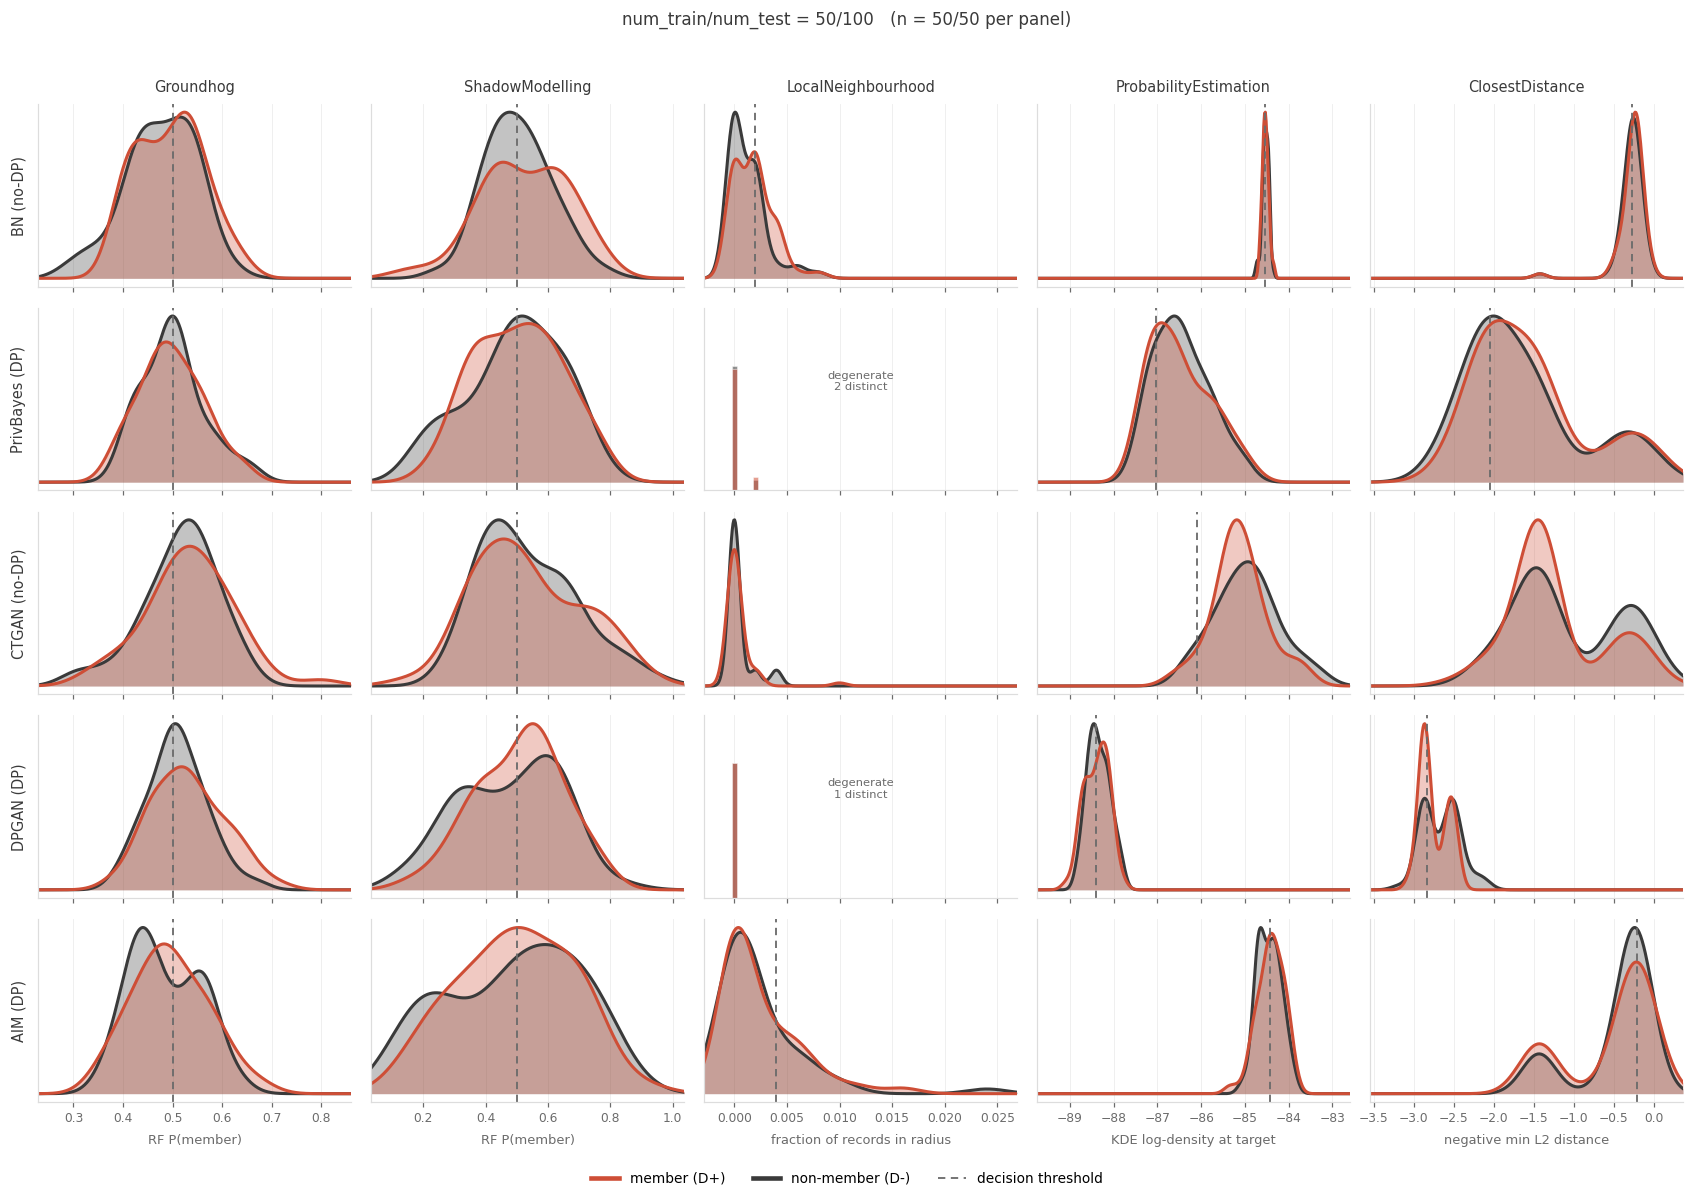

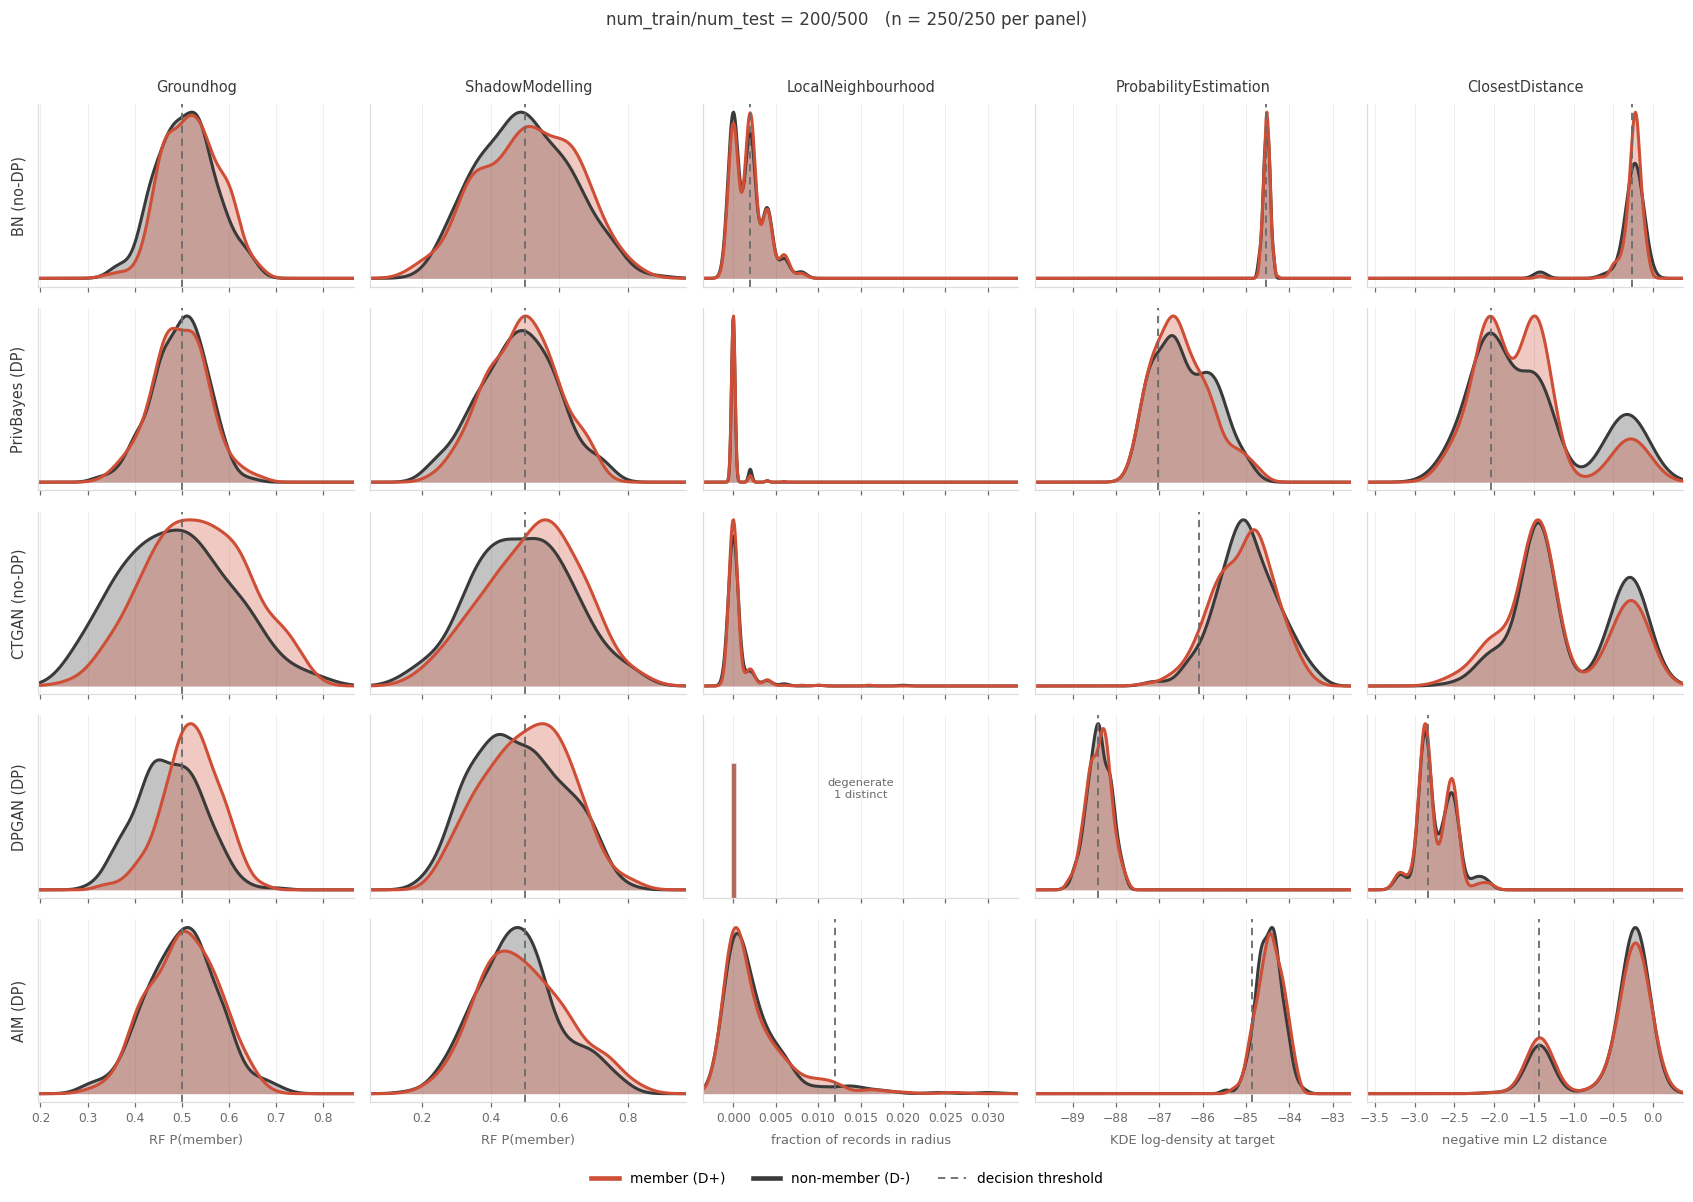

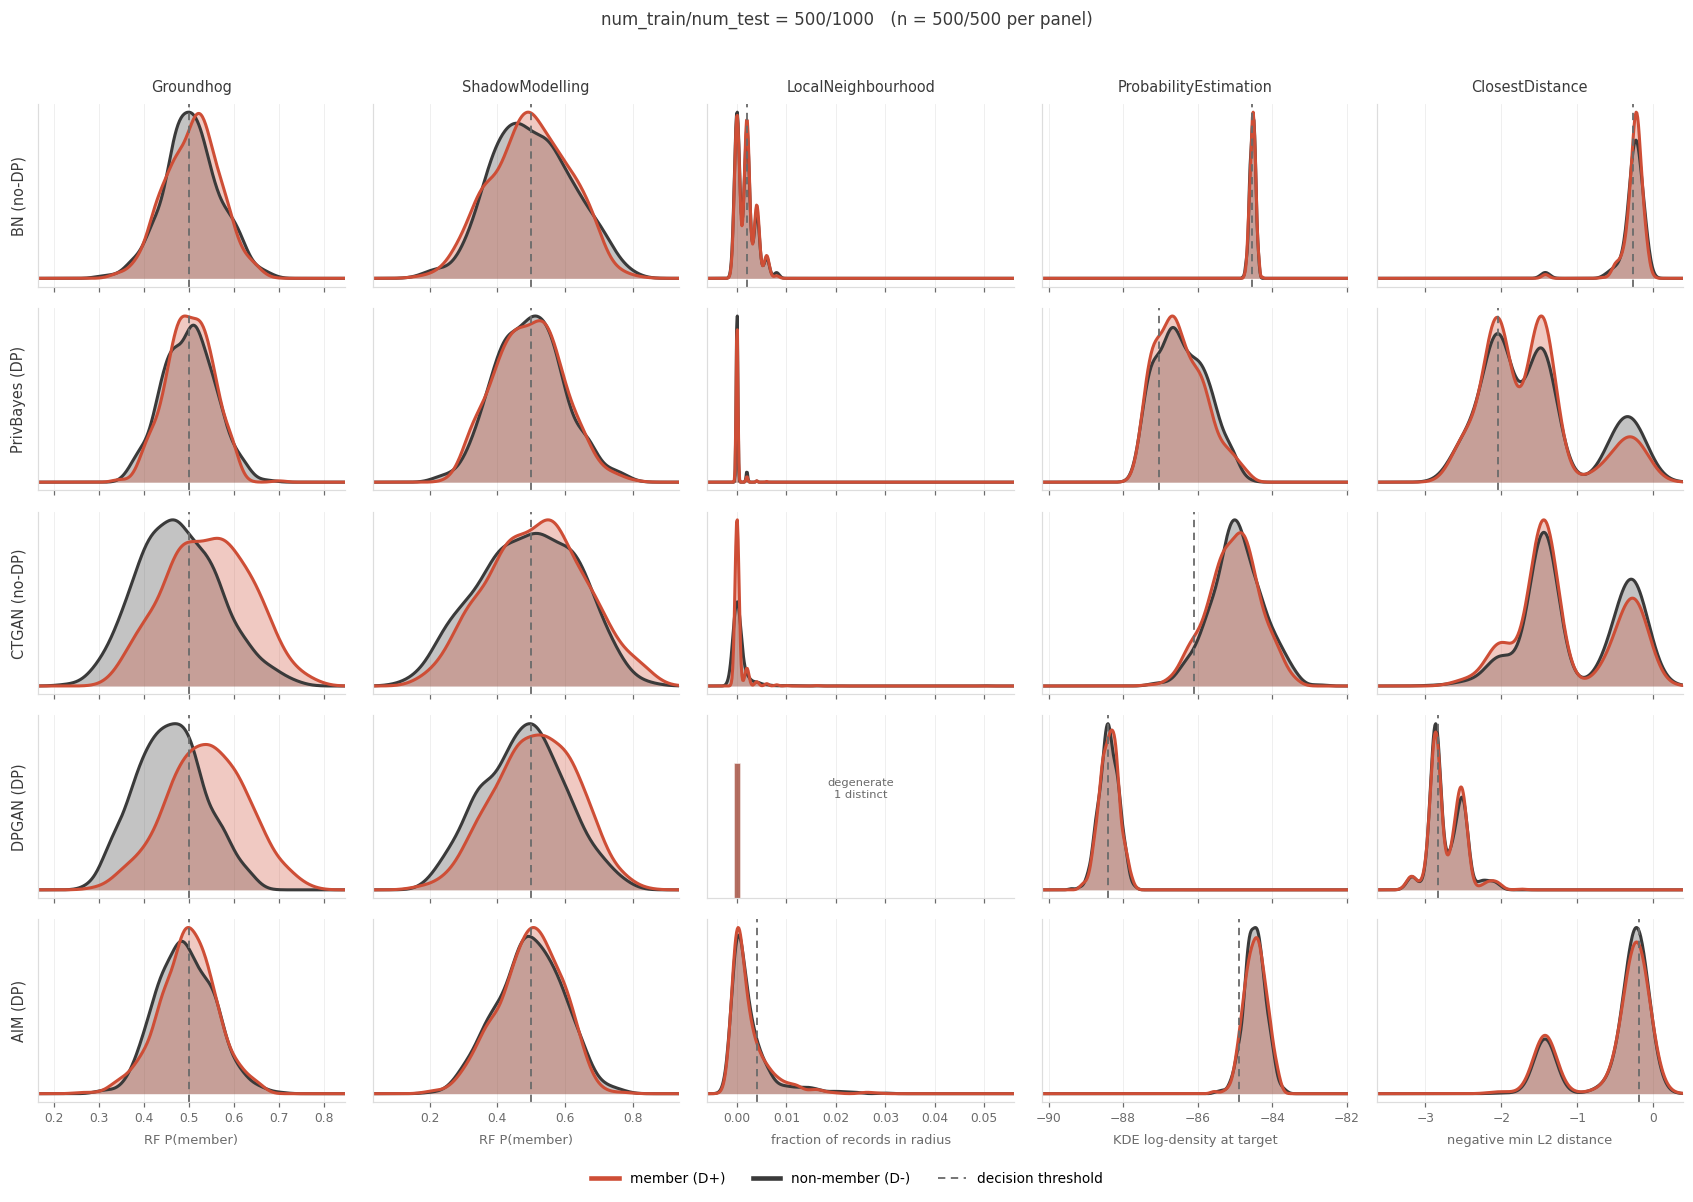

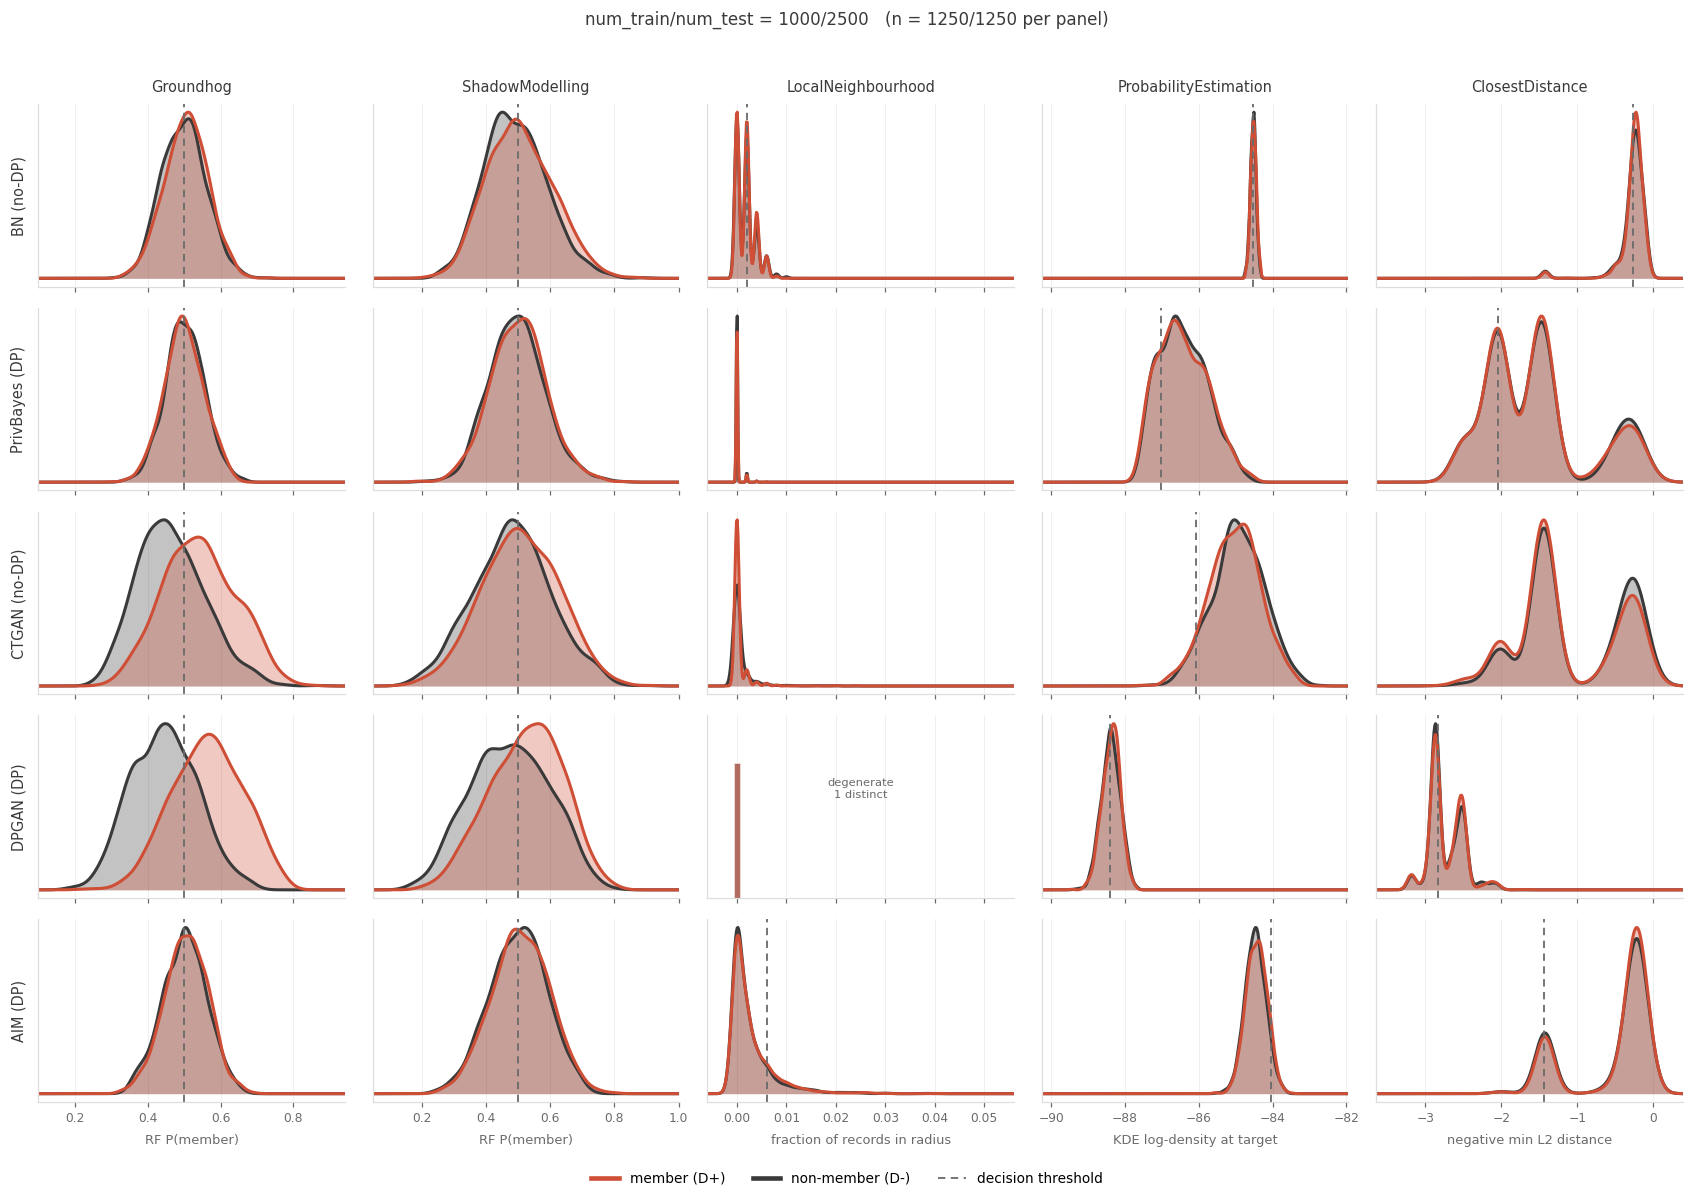

In [115]:
for ntr, nte in AVAIL:
    st = f"{ntr}_{nte}"
    sc = SCORES[st]
    attacks = [a for a in ATTACK_ORDER if a in set(sc.attack_short)]
    fig, axes = plt.subplots(len(GENS), len(attacks), sharex="col",
                             figsize=(3.1 * len(attacks), 2.15 * len(GENS)), squeeze=False)
    for c, atk in enumerate(attacks):
        sub = sc[sc.attack_short == atk]
        lo, hi = sub.raw_score.min(), sub.raw_score.max()
        pad = (hi - lo) * 0.12 if hi > lo else 0.5
        grid = np.linspace(lo - pad, hi + pad, 400)
        for r, gen in enumerate(GENS):
            ax = axes[r][c]
            g = sub[sub.generator == gen]
            mem = g[g.ground_truth == 1].raw_score.values
            non = g[g.ground_truth == 0].raw_score.values
            dm, dn = density(mem, grid), density(non, grid)
            if dm is None or dn is None:
                w = (grid[-1] - grid[0]) / 60
                for vals, col in ((non, CHARCOAL), (mem, ORANGE)):
                    u, cts = np.unique(vals, return_counts=True)
                    ax.bar(u, cts / cts.sum(), width=w, color=col, alpha=.55,
                           edgecolor="white", lw=.5)
                ax.set_ylim(0, 1.35)
                ax.text(.5, .55, f"degenerate\n{g.raw_score.nunique()} distinct",
                        transform=ax.transAxes, ha="center", fontsize=7.5, color=MUTED)
            else:
                ax.fill_between(grid, dn, color=CHARCOAL, alpha=.30, lw=0)
                ax.fill_between(grid, dm, color=ORANGE, alpha=.30, lw=0)
                ax.plot(grid, dn, color=CHARCOAL, lw=2)
                ax.plot(grid, dm, color=ORANGE, lw=2)
            thr = g.threshold.iloc[0]
            if np.isfinite(thr) and grid[0] <= thr <= grid[-1]:
                ax.axvline(thr, color=MUTED, ls=(0, (4, 3)), lw=1.2)
            ax.set_xlim(grid[0], grid[-1]); ax.set_yticks([]); tidy(ax)
            ax.grid(axis="x", color=GRID, lw=.6, alpha=.5)
            if r == 0: ax.set_title(atk, fontsize=9.5, color=INK, pad=8)
            if c == 0: ax.set_ylabel(LABELS[gen], fontsize=9.5, color=INK, labelpad=8)
            if r == len(GENS) - 1:
                ax.set_xlabel(SCORE_LABEL.get(atk, "score"), fontsize=8.5, color=MUTED, labelpad=6)
    fig.legend(handles=[Line2D([], [], color=ORANGE, lw=3, label="member (D+)"),
                        Line2D([], [], color=CHARCOAL, lw=3, label="non-member (D-)"),
                        Line2D([], [], color=MUTED, ls=(0, (4, 3)), lw=1.2, label="decision threshold")],
               loc="lower center", ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(.5, -.004))
    fig.suptitle(f"num_train/num_test = {ntr}/{nte}   (n = {nte//2}/{nte//2} per panel)",
                 fontsize=11, color=INK, y=1.0)
    fig.tight_layout(rect=[0, .025, 1, .985])
    fig.savefig(FIGURES_DIR / f"separation_{st}.png", bbox_inches="tight")
    plt.show()

## 2. Mann-Whitney U test

Two-sided, tie-corrected. H0: member and non-member raw scores share a distribution.

In [116]:
ALPHA = 0.05
MW = {}
for ntr, nte in AVAIL:
    st = f"{ntr}_{nte}"; sc = SCORES[st]
    rows = []
    for gen in GENS:
        for atk in [a for a in ATTACK_ORDER if a in set(sc.attack_short)]:
            cell = sc[(sc.generator == gen) & (sc.attack_short == atk)]
            m = cell[cell.ground_truth == 1].raw_score.values
            n = cell[cell.ground_truth == 0].raw_score.values
            U, p = mannwhitneyu(m, n, alternative="two-sided")
            rows.append(dict(generator=SHORT[gen], attack=atk, p=p, auc=U / (len(m) * len(n))))
    MW[st] = pd.DataFrame(rows)
    tbl = MW[st].pivot(index="generator", columns="attack", values="p")
    tbl = tbl.reindex(index=[SHORT[g] for g in GENS],
                      columns=[a for a in ATTACK_ORDER if a in tbl.columns])
    n_sig = int((MW[st].p < ALPHA).sum())
    print(f"\n=== {ntr}/{nte} ===   significant at p<{ALPHA}: {n_sig} of {len(MW[st])}"
          f"   (Bonferroni {ALPHA}/{len(MW[st])} = {ALPHA/len(MW[st]):.4f}: "
          f"{int((MW[st].p < ALPHA/len(MW[st])).sum())})")
    print(tbl.round(4).to_string())


=== 50/100 ===   significant at p<0.05: 0 of 25   (Bonferroni 0.05/25 = 0.0020: 0)
attack     Groundhog  ShadowModelling  LocalNeighbourhood  ProbabilityEstimation  ClosestDistance
generator                                                                                        
BN            0.3167           0.3643              0.0752                 0.5510           0.1733
PrivBayes     0.8063           0.9203              0.7333                 0.6867           0.5015
CTGAN         0.3374           0.9368              0.5255                 0.2344           0.5789
DPGAN         0.1500           0.4317              1.0000                 0.6124           0.0515
AIM           0.5210           0.9862              0.7906                 0.4259           0.9670

=== 200/500 ===   significant at p<0.05: 5 of 25   (Bonferroni 0.05/25 = 0.0020: 2)
attack     Groundhog  ShadowModelling  LocalNeighbourhood  ProbabilityEstimation  ClosestDistance
generator                                      

## 3. Classification metrics and effective epsilon

In [117]:
COLS = ["auc", "tp", "fp", "mia_advantage", "privacy_gain",
        "eff_epsilon_pointwise", "eps_low_95", "eps_high_95"]
for ntr, nte in AVAIL:
    st = f"{ntr}_{nte}"; m = METRICS[st].copy()
    m["generator"] = m.method.map(SHORT)
    m = m.sort_values(["method", "attack_short"],
                      key=lambda s: s.map({g: i for i, g in enumerate(GENS)}) if s.name == "method" else s)
    out = m[["generator", "attack_short"] + [c for c in COLS if c in m]]
    out = out.rename(columns={"attack_short": "attack", "mia_advantage": "advantage",
                              "eff_epsilon_pointwise": "eps_point",
                              "eps_low_95": "eps_lo95", "eps_high_95": "eps_hi95"})
    print(f"\n=== {ntr}/{nte} ===")
    print(out.to_string(index=False, float_format=lambda v: f"{v:.3f}"))


=== 50/100 ===
generator                attack   auc    tp    fp  advantage  privacy_gain  eps_point  eps_lo95  eps_hi95
       BN       ClosestDistance 0.579 0.760 0.560      0.200         0.800      0.693     0.000     0.282
       BN             Groundhog 0.558 0.480 0.400      0.080         0.920      0.981     0.000     0.193
       BN    LocalNeighbourhood 0.595 0.620 0.460      0.160         0.840      0.788     0.000     0.102
       BN ProbabilityEstimation 0.465 0.600 0.620     -0.020         1.020      0.182     0.000     0.294
       BN       ShadowModelling 0.553 0.520 0.520      0.000         1.000      0.811     0.000     0.128
PrivBayes       ClosestDistance 0.539 0.680 0.640      0.040         0.960      0.847     0.000     0.150
PrivBayes             Groundhog 0.486 0.440 0.400      0.040         0.960      0.262     0.000     0.139
PrivBayes    LocalNeighbourhood 0.510 0.000 0.000      0.000         1.000      0.000     0.000     0.102
PrivBayes ProbabilityEstimatio

## 4. MIA AUC against the null band

Band width depends on num_test, so it narrows at every stage.

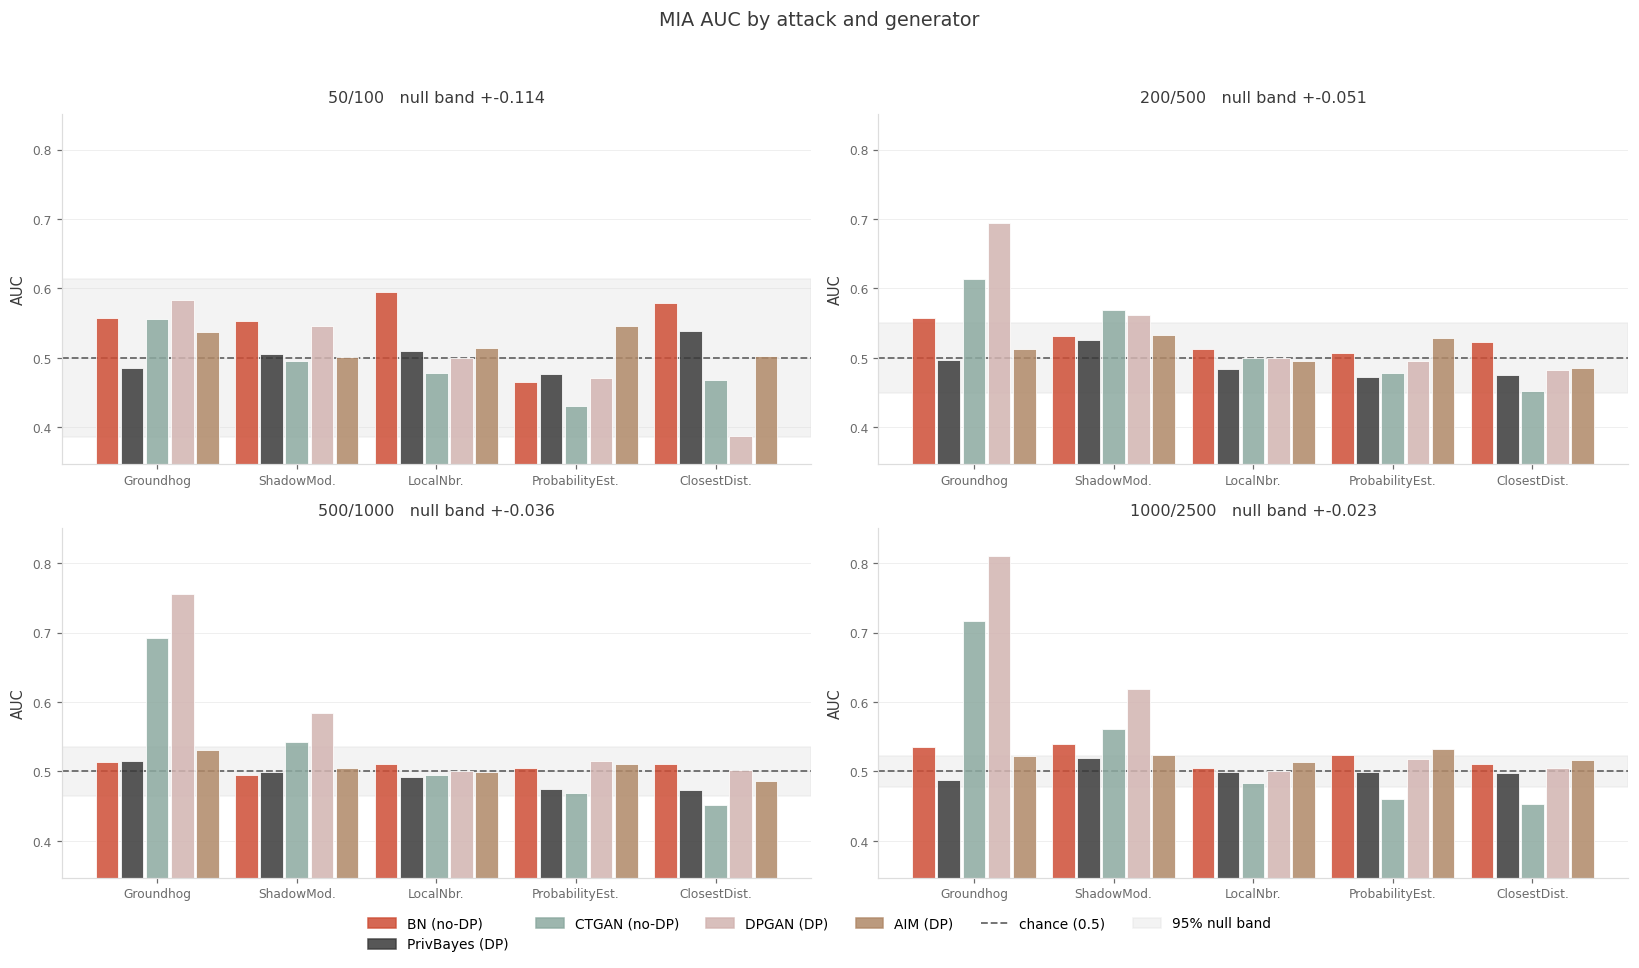

In [118]:
allauc = pd.concat([MW[f"{a}_{b}"].assign(stage=f"{a}/{b}") for a, b in AVAIL])
ylo, yhi = allauc.auc.min() - .04, allauc.auc.max() + .04

fig, axes = plt.subplots(2, 2, figsize=(15, 8.5), squeeze=False)
for k, (ntr, nte) in enumerate(AVAIL):
    ax = axes[k // 2][k % 2]
    st = f"{ntr}_{nte}"; hw = BANDS[st]
    piv = MW[st].pivot(index="attack", columns="generator", values="auc")
    attacks = [a for a in ATTACK_ORDER if a in piv.index]
    piv = piv.loc[attacks, [SHORT[g] for g in GENS]]
    x = np.arange(len(attacks)); width = .18
    offs = np.arange(len(GENS)) - (len(GENS) - 1) / 2
    ax.axhspan(.5 - hw, .5 + hw, color=GRID, alpha=.35, zorder=0)
    ax.axhline(.5, color=MUTED, ls="--", lw=1.2, zorder=1)
    for i, gen in enumerate(GENS):
        ax.bar(x + offs[i] * width, piv[SHORT[gen]].values, width * .9,
               color=GEN_COLOR[gen], alpha=.85, edgecolor="white", lw=.6, zorder=2,
               label=LABELS[gen] if k == 0 else None)
    ax.set_xticks(x); ax.set_xticklabels([SHORT_ATK[a] for a in attacks], fontsize=8.5)
    ax.set_ylim(ylo, yhi); ax.set_ylabel("AUC", fontsize=9.5, color=INK)
    ax.set_title(f"{ntr}/{nte}   null band +-{hw:.3f}", fontsize=10.5, color=INK, pad=8)
    tidy(ax); ax.grid(axis="y", color=GRID, lw=.6, alpha=.5)
handles = [plt.Rectangle((0, 0), 1, 1, color=GEN_COLOR[g], alpha=.85) for g in GENS] + \
          [Line2D([], [], color=MUTED, ls="--", lw=1.2), plt.Rectangle((0, 0), 1, 1, color=GRID, alpha=.35)]
fig.legend(handles=handles, labels=[LABELS[g] for g in GENS] + ["chance (0.5)", "95% null band"],
           loc="lower center", ncol=6, frameon=False, fontsize=9, bbox_to_anchor=(.5, -.02))
fig.suptitle("MIA AUC by attack and generator", fontsize=12.5, color=INK, y=1.0)
fig.tight_layout(rect=[0, .03, 1, .97])
fig.savefig(FIGURES_DIR / "auc_bar_chart.png", bbox_inches="tight")
plt.show()

## 5. Privacy-utility tradeoff

X: TSTR XGBoost AUC (mean over seeds). Y: mean MIA advantage (TP-FP) over the 5 attacks.

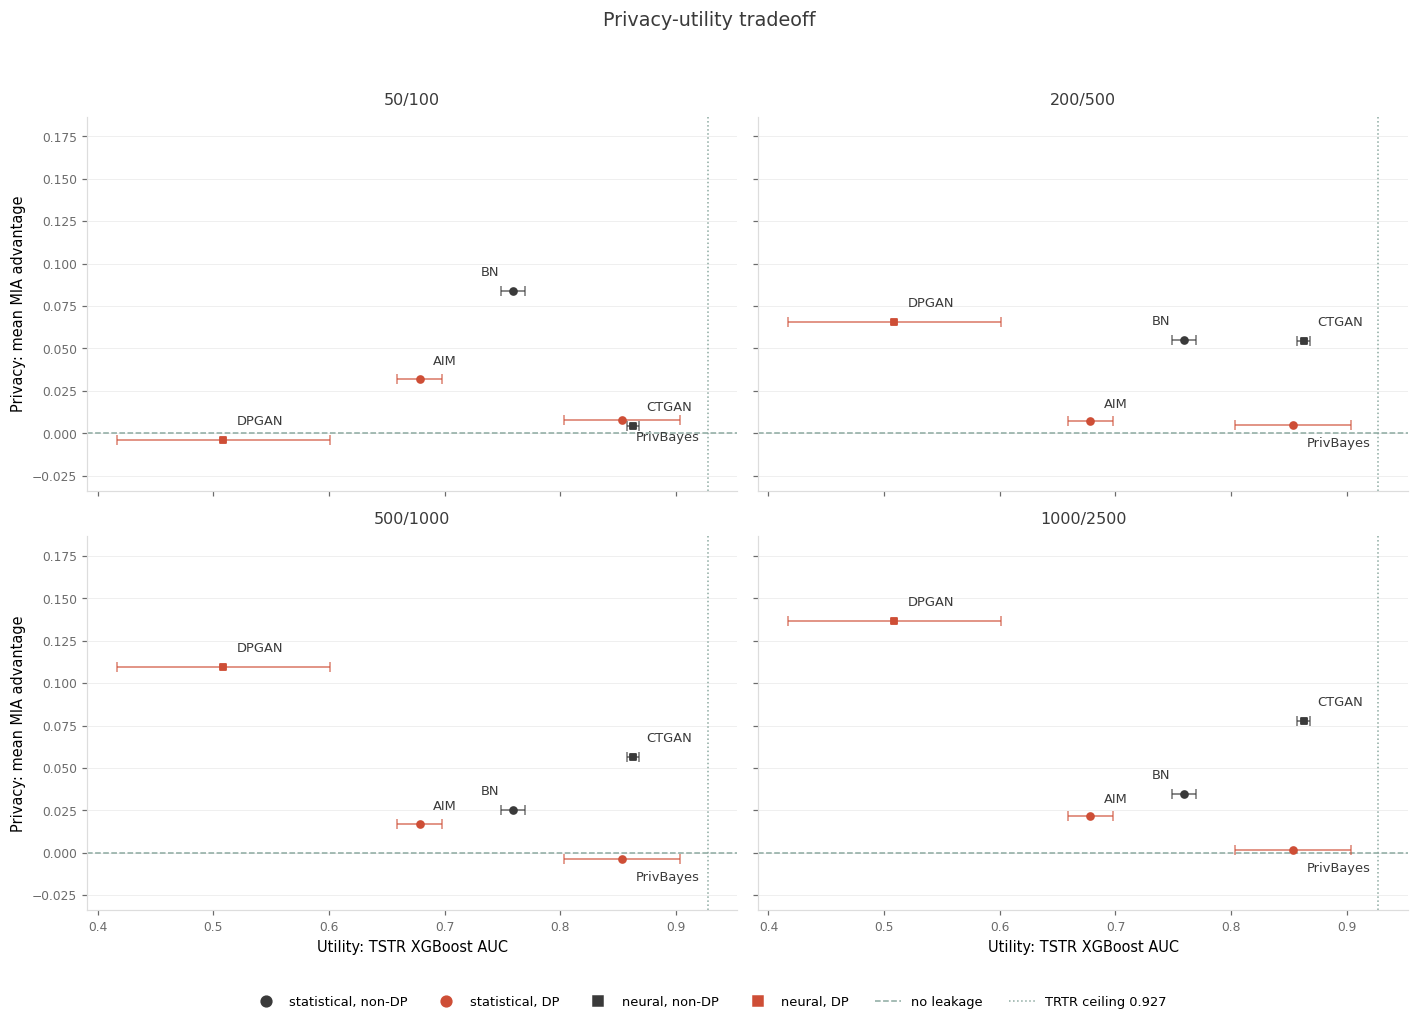

In [119]:
util = pd.read_csv(UTILITY_RESULTS)
adv_all = pd.concat([METRICS[f"{a}_{b}"].groupby("method").mia_advantage.mean()
                     .rename(f"{a}/{b}") for a, b in AVAIL], axis=1)
ylo2, yhi2 = adv_all.min().min() - .03, adv_all.max().max() + .05
gt = float(util.trtr_xgboost_auc_mean.dropna().iloc[0])

fig, axes = plt.subplots(2, 2, figsize=(13, 9), squeeze=False, sharex=True, sharey=True)
for k, (ntr, nte) in enumerate(AVAIL):
    ax = axes[k // 2][k % 2]
    adv = METRICS[f"{ntr}_{nte}"].groupby("method").mia_advantage.mean()
    ax.axhline(0, color=SAGE, ls="--", lw=1)
    ax.axvline(gt, color=SAGE, ls=":", lw=1)
    for gen in GENS:
        u = util[util.method == gen]
        if not len(u): continue
        xm, xs = float(u.tstr_xgboost_auc_mean.iloc[0]), float(u.tstr_xgboost_auc_std.iloc[0])
        dp, kind = METHOD_CONFIG[gen]["dp"], METHOD_CONFIG[gen]["kind"]
        col = ORANGE if dp else CHARCOAL       # DP orange, non-DP dark grey
        ax.errorbar(xm, adv[gen], xerr=xs, fmt="none", ecolor=col, elinewidth=1.1,
                    capsize=3, alpha=.7)
        # All markers filled: DP status is already carried by colour (orange vs charcoal,
        # which passes CVD separation), so the hollow/filled channel is redundant.
        ax.scatter(xm, adv[gen], s=20, marker="o" if kind == "statistical" else "s",
                   facecolor=col, edgecolor=col, lw=1.2, zorder=3)
        # PrivBayes and CTGAN sit almost on top of each other on the utility axis,
        # so their labels are pushed to opposite sides.
        dx, dy = {"privbayes": (9, -14), "ctgan": (9, 10),
                  "bayesian_network": (-9, 10), "dpgan": (9, 10)}.get(gen, (9, 9))
        ax.annotate(SHORT[gen], (xm, adv[gen]), textcoords="offset points",
                    xytext=(dx, dy), fontsize=8.5, color=INK,
                    ha="left" if dx > 0 else "right")
    ax.set_title(f"{ntr}/{nte}", fontsize=10.5, color=INK, pad=8)
    ax.set_ylim(ylo2, yhi2); tidy(ax); ax.grid(axis="y", color=GRID, lw=.6, alpha=.5)
    if k // 2 == 1: ax.set_xlabel("Utility: TSTR XGBoost AUC", fontsize=9.5)
    if k % 2 == 0: ax.set_ylabel("Privacy: mean MIA advantage", fontsize=9.5)
fig.legend(handles=[
    Line2D([], [], marker="o", ls="none", mfc=CHARCOAL, mec=CHARCOAL, ms=7, label="statistical, non-DP"),
    Line2D([], [], marker="o", ls="none", mfc=ORANGE, mec=ORANGE, ms=7, label="statistical, DP"),
    Line2D([], [], marker="s", ls="none", mfc=CHARCOAL, mec=CHARCOAL, ms=7, label="neural, non-DP"),
    Line2D([], [], marker="s", ls="none", mfc=ORANGE, mec=ORANGE, ms=7, label="neural, DP"),
    Line2D([], [], color=SAGE, ls="--", lw=1, label="no leakage"),
    Line2D([], [], color=SAGE, ls=":", lw=1, label=f"TRTR ceiling {gt:.3f}")],
    loc="lower center", ncol=6, frameon=False, fontsize=8.5, bbox_to_anchor=(.5, -.02))
fig.suptitle("Privacy-utility tradeoff", fontsize=12.5, color=INK, y=1.0)
fig.tight_layout(rect=[0, .03, 1, .97])
fig.savefig(FIGURES_DIR / "privacy_utility_tradeoff.png", bbox_inches="tight")
plt.show()

## 6. Formal epsilon sweep — DPGAN

**DRAFT — results land after the overnight run.** Every cell below no-ops with a
message until `results/eps_sweep/eps_sweep_summary.csv` exists.

Sections 1–5 vary the audit size at a fixed formal budget of ε = 1.0. This section holds
the audit size at 1000/2500 and varies ε instead, for DPGAN only, following
Chida et al. (MDAI 2024) — who swept PrivBayes at ε ∈ {0.1, 1, 10, 100} and audited with
TAPAS at exactly these counts. Applying that design to a DP-SGD **neural** generator is
the new part.

| | |
|---|---|
| ε swept | 0.1, 1.0, 10, 100 (ε = 1.0 reused from §1–5, not re-run) |
| audit | 1000/2500, 5-attack MIA battery, same background / target / attacks |
| utility | 5 seeds on the full 21,523-row split, TSTR/TRTR + 4 fidelity metrics |
| source | `scripts/eps_sweep/run_eps_sweep.py`, `eps_sweep_{generate,evaluate,aggregate}.py` |

**Three caveats to carry into any reading of these panels.**

1. **σ is not a function of ε alone.** Opacus solves for the noise multiplier from
   (ε, δ, sample_rate, epochs), and synthcity derives δ and the sample rate from
   whatever frame it is handed. The audited 500-row world and the 21,523-row utility
   world therefore run at *different* σ **and different δ** at the same nominal ε —
   σ ≈ 11.7 vs ≈ 2.7 at ε = 1.0. The privacy panel and the utility panel are not
   measuring the same mechanism, and no amount of extra audit samples fixes that.
2. **δ moves with n and is not pinned** (`gan.py:590–591`, `dp_delta = 1/len(X)`).
   Left alone deliberately — pinning it would make this sweep a different mechanism
   from every other DPGAN number in the repo.
3. **`poisson_sampling=False`** (`gan.py:607`) while the accountant that produced σ
   assumes Poisson subsampling. The formal guarantee is an approximation throughout,
   so ε_eff exceeding ε would not by itself prove an implementation fault.

ε is reported as passed to synthcity. Opacus accounts under add/remove while this
threat model *swaps* one record for another, so the comparable replacement-relation
budget is 2ε — plotted as a second reference line, not folded into the axis.


In [120]:
# ---- load the sweep (no-op until the overnight run lands) ----
EPS_DIR = BENCH / "results" / "eps_sweep"
EPS_SUMMARY = EPS_DIR / "eps_sweep_summary.csv"
EPS_PER_ATTACK = EPS_DIR / "privacy" / "eps_sweep_privacy_per_attack.csv"

EPS = pd.read_csv(EPS_SUMMARY) if EPS_SUMMARY.exists() else None
EPS_ATK = pd.read_csv(EPS_PER_ATTACK) if EPS_PER_ATTACK.exists() else None

if EPS is None:
    print(f"not found: {EPS_SUMMARY.relative_to(BENCH)}\n"
          "Run, in order:\n"
          "  python benchmark_tapas/scripts/eps_sweep/eps_sweep_sigma_check.py\n"
          "  python benchmark_tapas/scripts/eps_sweep/eps_sweep_generate.py\n"
          "  python benchmark_tapas/scripts/eps_sweep/eps_sweep_evaluate.py\n"
          "  python benchmark_tapas/scripts/eps_sweep/run_eps_sweep.py        # ~13 h\n"
          "  python benchmark_tapas/scripts/eps_sweep/eps_sweep_aggregate.py")
else:
    EPS = EPS.sort_values("formal_epsilon").reset_index(drop=True)
    done = EPS.worst_case_eff_eps_low.notna().sum() if "worst_case_eff_eps_low" in EPS else 0
    print(f"{len(EPS)} eps arms | {done} with privacy | "
          f"eps = {', '.join(f'{e:g}' for e in EPS.formal_epsilon)}")
    cols = [c for c in ["formal_epsilon", "sigma_audit", "sigma_utility",
                        "tstr_auc_xgb_mean", "KSComplement_mean",
                        "worst_case_eff_eps_low", "worst_case_eff_eps_high",
                        "worst_case_attack", "degenerate_pool"] if c in EPS.columns]
    display(EPS[cols].style.format(precision=3).hide(axis="index"))


4 eps arms | 4 with privacy | eps = 0.1, 1, 10, 100


formal_epsilon,sigma_audit,sigma_utility,tstr_auc_xgb_mean,KSComplement_mean,worst_case_eff_eps_low,worst_case_eff_eps_high,worst_case_attack,degenerate_pool
0.100,80.000,22.500,0.528,0.224,0.000,0.423,Groundhog,False
1.000,11.719,2.656,0.509,0.289,1.761,2.780,Groundhog,False
10.000,2.014,0.688,0.435,0.321,0.000,0.009,Groundhog,False
100.000,0.527,0.352,0.531,0.280,0.000,0.010,Groundhog,False


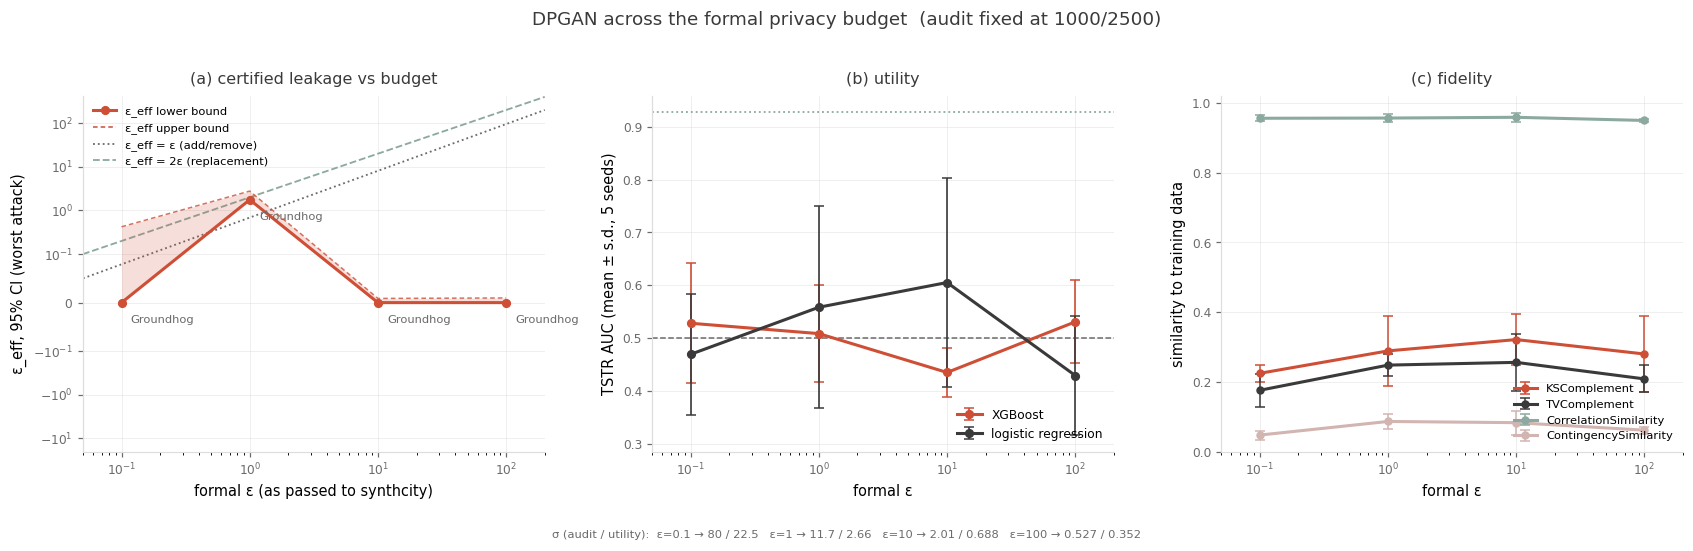

In [121]:
# ---- three panels against formal epsilon (log x throughout) ----
if EPS is None:
    print("skipped: run the sweep first (see the cell above)")
else:
    have = EPS.dropna(subset=["worst_case_eff_eps_low"]) if "worst_case_eff_eps_low" in EPS else EPS.iloc[:0]
    x = EPS.formal_epsilon.values
    lo, hi = x.min() / 2, x.max() * 2

    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5))

    # (a) certified leakage vs the budget that was paid for.
    ax = axes[0]
    ax.plot([lo, hi], [lo, hi], color=MUTED, ls=":", lw=1.2, zorder=1)
    ax.plot([lo, hi], [2 * lo, 2 * hi], color=SAGE, ls="--", lw=1.2, zorder=1)
    if len(have):
        xs = have.formal_epsilon.values
        elo, ehi = have.worst_case_eff_eps_low.values, have.worst_case_eff_eps_high.values
        ax.fill_between(xs, elo, ehi, color=ORANGE, alpha=.18, lw=0)
        ax.plot(xs, elo, color=ORANGE, lw=2, marker="o", ms=5, zorder=3)
        ax.plot(xs, ehi, color=ORANGE, lw=1, ls=(0, (3, 2)), alpha=.8, zorder=3)
        for _, r in have.iterrows():
            ax.annotate(str(r.worst_case_attack), (r.formal_epsilon, r.worst_case_eff_eps_low),
                        textcoords="offset points", xytext=(6, -13), fontsize=7.5, color=MUTED)
    ax.set_xscale("log"); ax.set_yscale("symlog", linthresh=0.1)
    ax.set_xlim(lo, hi)
    ax.set_xlabel("formal ε (as passed to synthcity)", fontsize=9.5)
    ax.set_ylabel("ε_eff, 95% CI (worst attack)", fontsize=9.5)
    ax.set_title("(a) certified leakage vs budget", fontsize=10.5, color=INK, pad=8)
    ax.legend(handles=[
        Line2D([], [], color=ORANGE, lw=2, marker="o", ms=5, label="ε_eff lower bound"),
        Line2D([], [], color=ORANGE, lw=1, ls=(0, (3, 2)), label="ε_eff upper bound"),
        Line2D([], [], color=MUTED, ls=":", lw=1.2, label="ε_eff = ε (add/remove)"),
        Line2D([], [], color=SAGE, ls="--", lw=1.2, label="ε_eff = 2ε (replacement)")],
        frameon=False, fontsize=7.5, loc="upper left")

    # (b) utility. TRTR is the same real-data ceiling at every eps.
    ax = axes[1]
    if "tstr_auc_xgb_mean" in EPS and EPS.tstr_auc_xgb_mean.notna().any():
        u = EPS.dropna(subset=["tstr_auc_xgb_mean"])
        if "trtr_auc_xgb" in u and u.trtr_auc_xgb.notna().any():
            ax.axhline(float(u.trtr_auc_xgb.dropna().iloc[0]), color=SAGE, ls=":", lw=1.2)
        ax.axhline(0.5, color=MUTED, ls="--", lw=1)
        for col, lbl, c in (("tstr_auc_xgb", "XGBoost", ORANGE),
                            ("tstr_auc_lr", "logistic regression", CHARCOAL)):
            if f"{col}_mean" not in u: continue
            m, s = u[f"{col}_mean"].values, u[f"{col}_std"].values
            ax.errorbar(u.formal_epsilon, m, yerr=s, color=c, lw=2, marker="o", ms=5,
                        capsize=3, elinewidth=1.1, label=lbl)
        ax.legend(frameon=False, fontsize=8, loc="lower right")
    ax.set_xscale("log"); ax.set_xlim(lo, hi)
    ax.set_xlabel("formal ε", fontsize=9.5)
    ax.set_ylabel("TSTR AUC (mean ± s.d., 5 seeds)", fontsize=9.5)
    ax.set_title("(b) utility", fontsize=10.5, color=INK, pad=8)

    # (c) fidelity. All four are similarity scores in [0,1], higher = better.
    ax = axes[2]
    FID = [("KSComplement", ORANGE), ("TVComplement", CHARCOAL),
           ("CorrelationSimilarity", SAGE), ("ContingencySimilarity", ROSE)]
    for name, c in FID:
        if f"{name}_mean" not in EPS or EPS[f"{name}_mean"].isna().all(): continue
        f = EPS.dropna(subset=[f"{name}_mean"])
        ax.errorbar(f.formal_epsilon, f[f"{name}_mean"], yerr=f[f"{name}_std"],
                    color=c, lw=2, marker="o", ms=4.5, capsize=3, elinewidth=1,
                    label=name)
    ax.set_xscale("log"); ax.set_xlim(lo, hi); ax.set_ylim(0, 1.02)
    ax.set_xlabel("formal ε", fontsize=9.5)
    ax.set_ylabel("similarity to training data", fontsize=9.5)
    ax.set_title("(c) fidelity", fontsize=10.5, color=INK, pad=8)
    ax.legend(frameon=False, fontsize=7.5, loc="lower right")

    for a in axes:
        tidy(a); a.grid(color=GRID, lw=.6, alpha=.5)
    # sigma is what eps actually buys; annotate rather than add a fourth panel.
    if "sigma_audit" in EPS:
        note = "σ (audit / utility):  " + "   ".join(
            f"ε={r.formal_epsilon:g} → {r.sigma_audit:.3g} / {r.sigma_utility:.3g}"
            for _, r in EPS.iterrows())
        fig.text(.5, -.045, note, ha="center", fontsize=7.5, color=MUTED)
    fig.suptitle("DPGAN across the formal privacy budget  (audit fixed at 1000/2500)",
                 fontsize=12, color=INK, y=1.02)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "eps_sweep_dpgan.png", bbox_inches="tight")
    plt.show()


In [122]:
# ---- per-attack detail: which attack sets the bound, and does that change with eps ----
if EPS_ATK is None:
    print("skipped: run the sweep first")
else:
    piv = (EPS_ATK.pivot_table(index="attack_short", columns="formal_epsilon",
                               values="eps_low_95")
           .reindex([a for a in ATTACK_ORDER if a in set(EPS_ATK.attack_short)]))
    print("ε_eff lower bound (95%) by attack x formal ε\n")
    print(piv.to_string(float_format=lambda v: f"{v:.3f}"))
    print("\nMIA advantage (TP - FP)\n")
    print(EPS_ATK.pivot_table(index="attack_short", columns="formal_epsilon",
                              values="mia_advantage")
          .reindex(piv.index).to_string(float_format=lambda v: f"{v:.3f}"))

    cols = [c for c in ["formal_epsilon", "attack_short", "auc", "tp", "fp", "tn", "fn",
                        "mia_advantage", "privacy_gain", "eps_low_95", "eps_high_95",
                        "eff_eps_tau", "eff_eps_tau_inverse"] if c in EPS_ATK.columns]
    display(EPS_ATK[cols].style.format(precision=3).hide(axis="index"))


ε_eff lower bound (95%) by attack x formal ε

formal_epsilon         0.1    1.0    10.0   100.0
attack_short                                     
Groundhog              0.000  1.761  0.000  0.000
ShadowModelling        0.000  0.241  0.000  0.000
LocalNeighbourhood     0.000  0.000  0.000  0.000
ProbabilityEstimation  0.000  0.000  0.000  0.000
ClosestDistance        0.000  0.000  0.000  0.000

MIA advantage (TP - FP)

formal_epsilon         0.1    1.0    10.0   100.0
attack_short                                     
Groundhog              0.066  0.452  0.041  0.133
ShadowModelling       -0.014  0.176  0.026  0.006
LocalNeighbourhood     0.000  0.000  0.000  0.000
ProbabilityEstimation  0.016  0.037  0.001  0.004
ClosestDistance        0.014  0.018  0.005  0.006


formal_epsilon,attack_short,auc,tp,fp,tn,fn,mia_advantage,privacy_gain,eps_low_95,eps_high_95,eff_eps_tau,eff_eps_tau_inverse
0.100,ClosestDistance,0.493,0.263,0.250,0.750,0.737,0.014,0.986,0.000,0.004,-2.139,0.000
0.100,Groundhog,0.549,0.514,0.449,0.551,0.486,0.066,0.934,0.000,0.423,0.570,0.000
0.100,LocalNeighbourhood,0.500,0.000,0.000,1.000,1.000,0.000,1.000,0.000,0.004,0.000,0.000
0.100,ProbabilityEstimation,0.519,0.298,0.282,0.718,0.702,0.016,0.984,0.000,0.009,-86.491,0.000
0.100,ShadowModelling,0.497,0.470,0.484,0.516,0.530,-0.014,1.014,0.000,0.004,0.180,0.000
1.000,ClosestDistance,0.504,0.457,0.438,0.562,0.543,0.018,0.982,0.000,0.006,nan,nan
1.000,Groundhog,0.811,0.720,0.268,0.732,0.280,0.452,0.548,1.761,2.780,nan,nan
1.000,LocalNeighbourhood,0.500,0.000,0.000,1.000,1.000,0.000,1.000,0.000,0.004,nan,nan
1.000,ProbabilityEstimation,0.517,0.578,0.542,0.458,0.422,0.037,0.963,0.000,0.013,nan,nan
1.000,ShadowModelling,0.619,0.588,0.412,0.588,0.412,0.176,0.824,0.241,0.572,nan,nan


### 6.1 Side by side with Chida et al.

The two cells below rebuild Chida et al.'s **Table 1** and **Fig. 4** on DPGAN, in their
layout and their row/panel order (ε = 100 → 0.1), so the two papers' results can be read
against each other directly. They add no new computation — the same per-attack CSV and
the same raw scores as above, presented their way.

**Why their format is worth adopting here.** The three-panel figure above answers "does ε
buy anything?" across privacy, utility and fidelity at once. Chida's format answers a
narrower question more sharply: *how far is the measured leakage from the budget that was
paid for, and does the confidence level change that answer?* Reporting all three
confidence levels (0.90 / 0.95 / 0.99) matters because ε_eff is a Clopper–Pearson
interval — a bound that widens as you demand more confidence — not a point estimate.

**The floor, and why matching digits are the point.** When an attack achieves nothing, the
interval collapses to a function of the sample count alone. With 2,500 test datasets that
floor is `[0, 0.003895]` at 95% — and Chida's PrivBayes rows at ε = 100 and ε = 10 report
exactly `0 / 0.003895` too. So a zero row here is not "a small amount of leakage"; it is
the smallest quantity this audit size can express, and DPGAN's ε = 100, 10 and 0.1 rows
land on the identical floor as their Bayesian-network generator. That a DP-SGD **neural**
generator reproduces the same floor is the transferable finding: the gap between formal
and empirical ε is not specific to PrivBayes or to marginal-based synthesis.

**Two departures from their result to note when citing this.**

1. **ε = 1.0 is the outlier, and it is the arm we trust least.** It is the only row above
   the floor, the only arm carrying a real membership signal (0.892 in-train, against
   0.512–0.569 at the other three budgets), and the only one generated by a different
   script on a different day. DP predicts leakage rising *with* ε, not spiking in the
   middle. Pending a like-for-like re-audit at ε = 1.0 through `run_eps_sweep.py`, treat
   that row as unresolved rather than as the headline.
2. **ε = 10's upper bound is ~5× the others** (0.020676 vs 0.003895 at 95%). Groundhog
   reached AUC 0.528 there — not enough to certify anything, but enough to lift the
   interval off the floor. Chida's rows show no comparable variation.


In [123]:
# ---- Chida et al. Table 1 equivalent: eff-epsilon at three confidence levels ----
if EPS_ATK is None:
    print("skipped: run the sweep first")
else:
    rows = []
    # Chida orders the rows 100 -> 0.1; worst case over attacks = the largest certified
    # lower bound, which is what EffectiveEpsilonReport reports for the mechanism.
    for eps in sorted(EPS_ATK.formal_epsilon.unique(), reverse=True):
        sub = EPS_ATK[EPS_ATK.formal_epsilon == eps]
        row = {"eps": eps}
        for c in (90, 95, 99):
            best = sub.loc[sub[f"eps_low_{c}"].idxmax()]
            row[f"{c / 100:.2f} (low)"] = best[f"eps_low_{c}"]
            row[f"{c / 100:.2f} (high)"] = best[f"eps_high_{c}"]
        row["attack"] = sub.loc[sub.eps_low_95.idxmax(), "attack_short"]
        rows.append(row)
    CHIDA_TAB = pd.DataFrame(rows).set_index("eps")
    CHIDA_TAB.to_csv(EPS_DIR / "privacy" / "eps_sweep_effeps_by_confidence.csv")   # full precision

    # Exact zeros print as "0", as in Chida's Table 1: a certified lower bound of zero
    # is an exact result, not a rounded small number, and "0.000000" reads as the latter.
    def fmt(v):
        return "0" if v == 0 else f"{v:.6f}"

    print("Effective epsilon (DPGAN), worst case over the 5 attacks\n")
    print(CHIDA_TAB.drop(columns="attack").to_string(float_format=fmt))

    # The Clopper-Pearson floor: with no leakage the interval depends only on the
    # sample count, so a zero row is not "a small number" -- it is the smallest number
    # 2500 test datasets can express. Chida's PrivBayes rows sit on the same floor.
    floor = CHIDA_TAB[CHIDA_TAB["0.95 (low)"] == 0]["0.95 (high)"]
    if len(floor):
        print(f"\nrows at the certified floor (eps_low = 0): "
              f"{', '.join(f'eps={i:g}' for i in floor.index)}")
        print(f"  their 95% upper bounds span {floor.min():.6f} to {floor.max():.6f}")


Effective epsilon (DPGAN), worst case over the 5 attacks

       0.90 (low)  0.90 (high)  0.95 (low)  0.95 (high)  0.99 (low)  0.99 (high)
eps                                                                             
100.0           0     0.003279           0     0.003895           0     0.005326
10.0            0     0.019049           0     0.020676           0     0.024009
1.0      1.817874     2.712220    1.761315     2.780174    1.649317     2.919485
0.1             0     0.003256           0     0.003884           0     0.005324

rows at the certified floor (eps_low = 0): eps=100, eps=10, eps=0.1
  their 95% upper bounds span 0.003884 to 0.020676


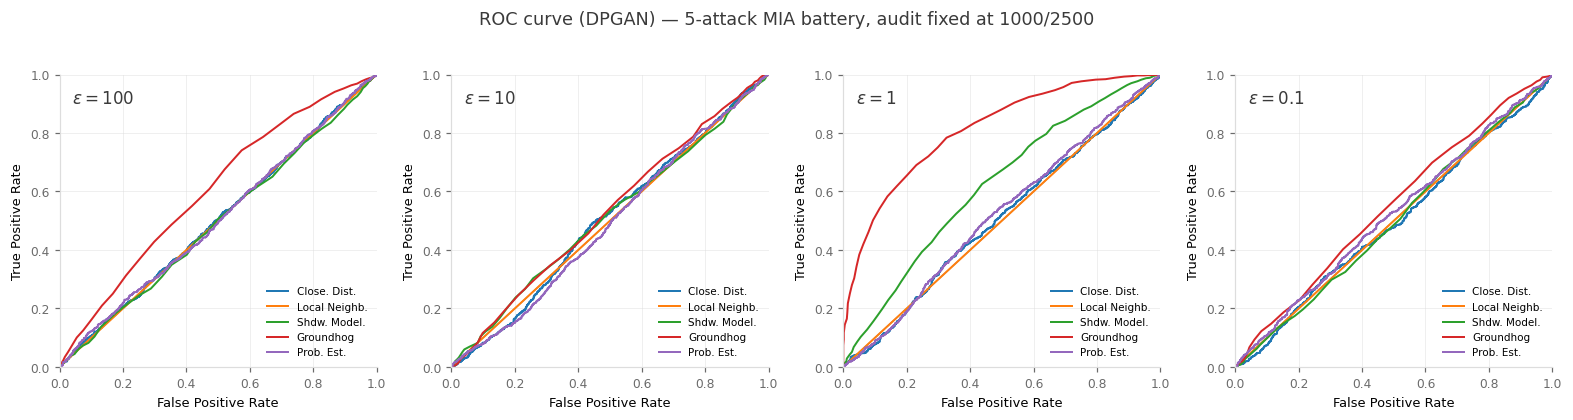

In [124]:
# ---- Chida et al. Fig 4 equivalent: one ROC panel per eps, all five attacks ----
from sklearn.metrics import roc_curve

# Chida's panel order (100 -> 0.1) and legend order, so the two figures read side by side.
CHIDA_EPS = [100.0, 10.0, 1.0, 0.1]
CHIDA_ATK = ["ClosestDistance", "LocalNeighbourhood", "ShadowModelling",
             "Groundhog", "ProbabilityEstimation"]
CHIDA_LBL = {"ClosestDistance": "Close. Dist.", "LocalNeighbourhood": "Local Neighb.",
             "ShadowModelling": "Shdw. Model.", "Groundhog": "Groundhog",
             "ProbabilityEstimation": "Prob. Est."}
# DELIBERATE DEPARTURE FROM THE REPO PALETTE. Chida et al. Fig. 4 was drawn with
# matplotlib's default tab10 cycle taken in this legend order, so reproducing those
# exact hues lets the two figures be laid side by side and read as one comparison.
# Every other figure in this notebook keeps the repo palette (ORANGE/CHARCOAL/SAGE/ROSE).
CHIDA_COL = {"ClosestDistance":       "#1f77b4",   # C0 blue
             "LocalNeighbourhood":    "#ff7f0e",   # C1 orange
             "ShadowModelling":       "#2ca02c",   # C2 green
             "Groundhog":             "#d62728",   # C3 red
             "ProbabilityEstimation": "#9467bd"}   # C4 purple


def dpgan_scores(eps):
    """Raw pre-threshold scores for one budget.

    eps=1.0 is the counts-sweep arm already loaded into SCORES by the setup cell;
    the other three come from this sweep's own raw-score CSVs.
    """
    if eps == 1.0:
        d = SCORES.get("1000_2500")
        return None if d is None else d[d.generator == "dpgan"]
    p = EPS_DIR / "privacy" / f"raw_scores_dpgan_eps{eps:g}.csv"
    if not p.exists():
        return None
    d = pd.read_csv(p)
    d["attack_short"] = d.attack.str.split("(").str[0]
    return d


panels = [(e, dpgan_scores(e)) for e in CHIDA_EPS]
panels = [(e, d) for e, d in panels if d is not None and len(d)]
if not panels:
    print("skipped: no raw-score CSVs found for the sweep")
else:
    fig, axes = plt.subplots(1, len(panels), figsize=(3.6 * len(panels), 3.7), squeeze=False)
    for ax, (eps, d) in zip(axes[0], panels):
        ax.plot([0, 1], [0, 1], color=MUTED, lw=.8, zorder=1)          # chance
        for atk in CHIDA_ATK:
            s = d[d.attack_short == atk]
            if s.empty:
                continue
            fpr, tpr, _ = roc_curve(s.ground_truth, s.raw_score)
            ax.plot(fpr, tpr, color=CHIDA_COL[atk], lw=1.3,
                    label=CHIDA_LBL[atk], zorder=2)
        ax.text(.04, .95, rf"$\varepsilon = {eps:g}$", fontsize=11, color=INK,
                transform=ax.transAxes, va="top")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xticks(np.arange(0, 1.01, .2)); ax.set_yticks(np.arange(0, 1.01, .2))
        ax.set_xlabel("False Positive Rate", fontsize=8.5)
        ax.set_ylabel("True Positive Rate", fontsize=8.5)
        tidy(ax); ax.grid(color=GRID, lw=.5, alpha=.6)
        ax.legend(frameon=False, fontsize=6.8, loc="lower right")
    fig.suptitle("ROC curve (DPGAN) — 5-attack MIA battery, audit fixed at 1000/2500",
                 fontsize=11.5, color=INK, y=1.02)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "eps_sweep_roc_dpgan.png", bbox_inches="tight")
    plt.show()


### 6.2 The ε = 1.0 peak is real — and it is a peak, not a spike

The sweep above shows leakage at ε = 1.0 and nothing at 0.1, 10 or 100. DP cannot produce
that shape: more budget should mean more leakage, monotonically. Two explanations fit those
four points equally well and need different responses — either leakage genuinely peaks near
ε ≈ 1, or something specific to that one run made it leak and ε is incidental.

A single elevated point cannot separate them, so `scripts/eps_sweep/spike_diagnosis/eps_sweep_signal_scan.py` added
neighbours at ε = 0.3 and ε = 3.0. It measures the membership signal **directly in the
generated pools** — a classifier on per-dataset summary features, cross-validated within the
training pool — rather than going through the attack battery and the Clopper–Pearson bound,
which clips at zero and so cannot distinguish "no leakage" from "a little".

| ε | signal | permuted baseline | gap |
|---|---|---|---|
| 0.3 | 0.757 | 0.554 | **+0.203** |
| 1.0 | 0.874 | 0.501 | **+0.373** |
| 3.0 | 0.615 | 0.424 | **+0.191** |

Both neighbours sit clearly above their own baselines, with ε = 1.0 highest. Stitched
together with the audit-pool measurements the curve is unimodal — rising from 0.1 to 1,
falling from 1 to 100. **A real interior maximum, not a spike.** And the fresh ε = 1.0 pool
scored 0.874 against the archived pool's 0.892, six days and a separate cache apart, so the
ε = 1.0 row in the sweep above is a reproducible measurement rather than an artefact of the
run that produced it.

**The mechanism this implies.** DPGAN's empirical privacy is worst at *moderate* noise. Too
much and the output is garbage that buries any signal; too little and the GAN trains
properly and produces a smoothed distribution. In between, the discriminator is damaged
enough that the generator's output is driven by CTGAN's data transformer and conditional
sampler — **neither of which is privatised**, both fit directly on the input rows including
the target — while the output is still clean enough for that imprint to be readable. So
"more budget ⇒ more leakage" fails empirically for this implementation, which is exactly the
class of theory-versus-practice gap Chida et al. set out to detect.

**Two caveats to carry into any write-up.**

1. The permuted baselines wander between 0.424 and 0.554 rather than sitting at 0.5, so the
   null has real variance at n = 400 from a single permutation. The gaps (0.19–0.37) are
   much larger than that wobble, so the conclusion holds — but for publication the baseline
   should be averaged over several permutations per point, not one.
2. The six points are not strictly like-for-like. ε = 0.1, 10 and 100 were measured on the
   **1000-dataset audit pools**; ε = 0.3, 1 and 3 on **400-dataset scan pools**. The
   fresh-vs-archived agreement at ε = 1.0 (0.874 vs 0.892) suggests the sample size does not
   matter much here, but the figure below marks which points came from which.

 formal_epsilon  n_datasets  signal_auc  signal_auc_cv_std  permuted_auc
          0.300         400       0.757              0.048         0.554
          1.000         400       0.874              0.014         0.501
          3.000         400       0.615              0.032         0.424


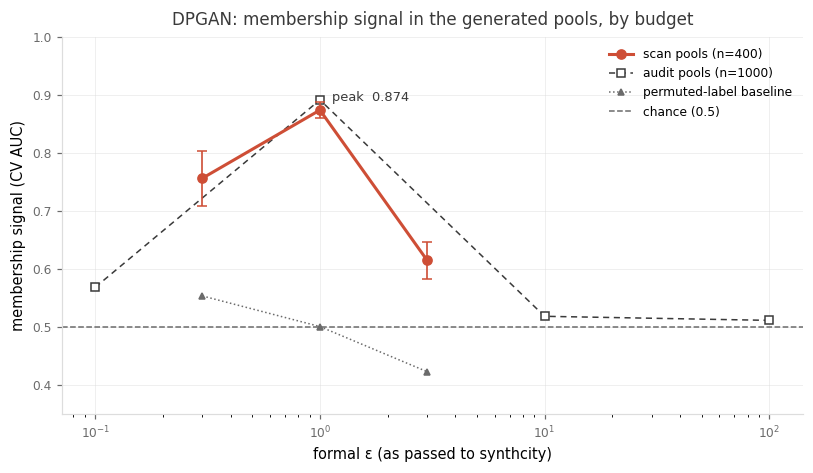

In [125]:
# ---- the membership-signal curve: is eps=1.0 a peak or a spike? ----
SCAN_CSV = EPS_DIR / "spike_diagnosis" / "signal_scan.csv"

# The three budgets measured on the 1000-dataset AUDIT pools rather than by the scan.
# Carried as constants because they were computed from cache/dpgan*/datasets/ exports,
# which are gitignored -- so they cannot be re-derived from anything in results/.
# Provenance: same feature set and same classifier as the scan, n=1000 instead of n=400.
AUDIT_POOL_SIGNAL = {0.1: 0.569, 1.0: 0.892, 10.0: 0.519, 100.0: 0.512}

if not SCAN_CSV.exists():
    print(f"not found: {SCAN_CSV.relative_to(BENCH)}\n"
          "  run: python benchmark_tapas/scripts/eps_sweep/spike_diagnosis/eps_sweep_signal_scan.py")
else:
    scan = pd.read_csv(SCAN_CSV).sort_values("formal_epsilon")
    print(scan[["formal_epsilon", "n_datasets", "signal_auc", "signal_auc_cv_std",
                "permuted_auc"]].to_string(index=False,
                                           float_format=lambda v: f"{v:.3f}"))

    fig, ax = plt.subplots(figsize=(7.5, 4.4))
    ax.axhline(0.5, color=MUTED, ls="--", lw=1)

    # audit-pool points first, so the scan curve draws over them
    ax_x = sorted(AUDIT_POOL_SIGNAL)
    ax.plot(ax_x, [AUDIT_POOL_SIGNAL[e] for e in ax_x], color=CHARCOAL, lw=1,
            ls=(0, (4, 3)), marker="s", ms=5, mfc="white", mec=CHARCOAL, zorder=2)

    ax.errorbar(scan.formal_epsilon, scan.signal_auc, yerr=scan.signal_auc_cv_std,
                color=ORANGE, lw=2, marker="o", ms=6, capsize=3, elinewidth=1.1, zorder=3)
    ax.plot(scan.formal_epsilon, scan.permuted_auc, color=MUTED, lw=1, ls=":",
            marker="^", ms=4, zorder=2)

    peak = scan.loc[scan.signal_auc.idxmax()]
    ax.annotate(f"peak  {peak.signal_auc:.3f}", (peak.formal_epsilon, peak.signal_auc),
                textcoords="offset points", xytext=(8, 6), fontsize=8.5, color=INK)

    ax.set_xscale("log")
    ax.set_ylim(0.35, 1.0)
    ax.set_xlabel("formal ε (as passed to synthcity)", fontsize=9.5)
    ax.set_ylabel("membership signal (CV AUC)", fontsize=9.5)
    ax.set_title("DPGAN: membership signal in the generated pools, by budget",
                 fontsize=11, color=INK, pad=8)
    ax.legend(handles=[
        Line2D([], [], color=ORANGE, lw=2, marker="o", ms=6, label="scan pools (n=400)"),
        Line2D([], [], color=CHARCOAL, lw=1, ls=(0, (4, 3)), marker="s", ms=5,
               mfc="white", label="audit pools (n=1000)"),
        Line2D([], [], color=MUTED, lw=1, ls=":", marker="^", ms=4,
               label="permuted-label baseline"),
        Line2D([], [], color=MUTED, ls="--", lw=1, label="chance (0.5)")],
        frameon=False, fontsize=8, loc="upper right")
    tidy(ax); ax.grid(color=GRID, lw=.6, alpha=.5)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "eps_sweep_signal_curve.png", bbox_inches="tight")
    plt.show()

### 6.3 Where does the spike come from? Isolating the cause

§6.2 established that the ε ≈ 1 peak is real and reproducible. This section asks *which
component produces it*. The measurement is a chain of four links, and the spike could
live in any of them:

```
synthcity DPGAN  →  generated data  →  TAPAS attacks  →  effective epsilon
      [3]                                    [0]              [1]
                        ↑ [2] is eps itself special near 1.0?
```

Four experiments, each swapping out one link:

| | what was swapped | result |
|---|---|---|
| **[0]** | the attacks — an independent classifier on the same pools | signal found anyway → **not the attacks** |
| **[1]** | the bound — Clopper–Pearson recomputed from raw scores | TAPAS is *conservative* → **not the arithmetic** |
| **[2]** | ε itself — 0.999 and 1.001, everything else identical | both still spike → **not the number 1.0** |
| **[3]** | the generator — SmartNoise DP-CTGAN, same TAPAS setup | flat at the floor → **not DP-SGD-on-CTGAN as a method** |

[0] is the curve in §6.2. The three panels below are [1], [2] and [3].

**Conclusion: the spike is specific to synthcity's DPGAN.** Every other link has been
ruled out, and an independent implementation of the same algorithm — trained to
completion at ε = 100, so not merely under-trained — shows no leakage at any budget.

**The caveat to carry.** "synthcity's implementation" is not yet narrowed to a single
cause, because the two libraries differ in more than their code: SmartNoise uses
`batch_size = 500` on a 500-row background (sampling rate 1.0, so no privacy
amplification), fixes σ = 5 rather than solving for it, and derives a different δ. The
sharpest remaining hypothesis is that synthcity's CTGAN preprocessing — VGM
mode-specific normalisation plus a conditional sampler, both fit on the **raw data with
no DP** — imprints the input distribution on the output, and that imprint dominates once
DP-SGD noise has destroyed the discriminator. Testing that would mean a matched arm
(DP-CTGAN at `batch_size = 200`) and inspecting what synthcity's transformer retains.

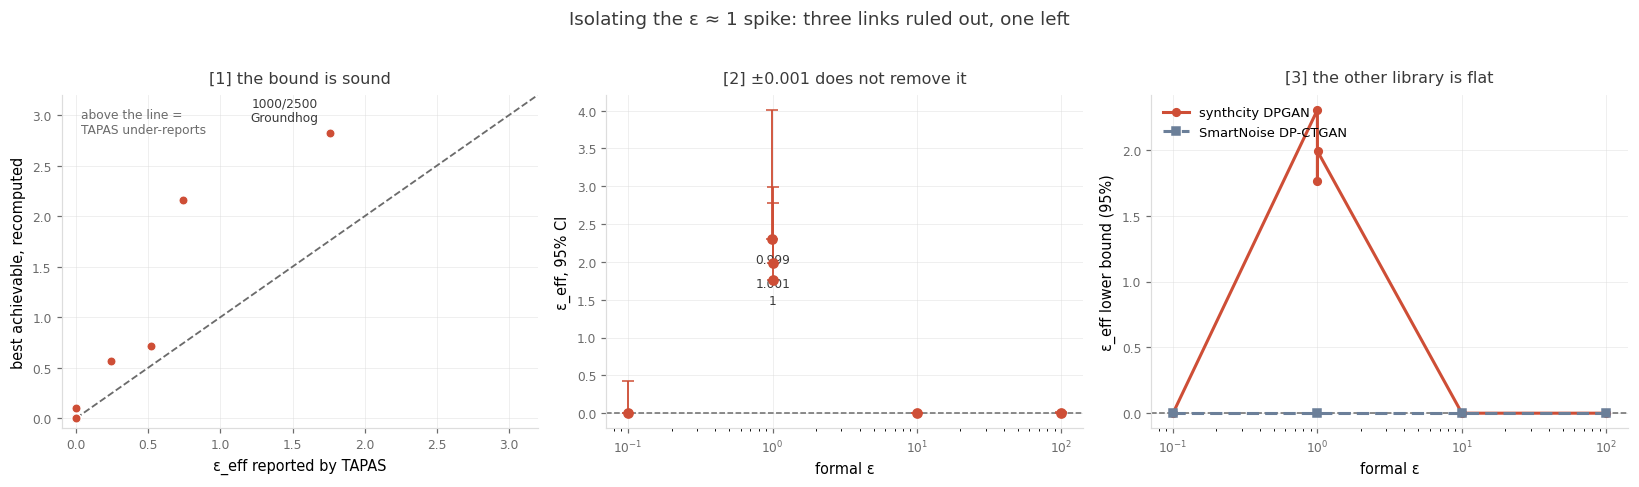

synthcity DPGAN, worst-case ε_eff by budget
   ε=0.1      0.000 [0.000, 0.423]
   ε=0.999    2.303 [2.303, 4.009]  <-- nudge
   ε=1        1.761 [1.761, 2.780]
   ε=1.001    1.989 [1.989, 2.993]  <-- nudge
   ε=10       0.000 [0.000, 0.009]
   ε=100      0.000 [0.000, 0.010]

SmartNoise DP-CTGAN, worst-case ε_eff by budget
   ε=0.1      0.000 [0.000, 0.008]
   ε=1        0.000 [0.000, 0.004]
   ε=10       0.000 [0.000, 0.010]
   ε=100      0.000 [0.000, 0.013]

[1] TAPAS exceeds the best achievable bound in 0 of 20 cells (0 = its arithmetic is sound)


In [127]:
# ---- three panels: what was ruled out, and what was not ----
DIAG = EPS_DIR / "spike_diagnosis"
SN = "#6B7F99"          # SmartNoise, distinct from the repo's four-method palette

# [1] independent recomputation of the bound
rec = pd.read_csv(DIAG / "recomputed_eff_eps.csv") if (DIAG / "recomputed_eff_eps.csv").exists() else None

# [2] the eps nudge, plus the four original arms for context
def _worst(path, col="eps_low_95"):
    d = pd.read_csv(path)
    r = d.loc[d[col].idxmax()]
    return float(r[col]), float(r["eps_high_95"])

nudge = {}
for e in (0.999, 1.001):
    p = DIAG / "privacy" / f"eps{e:g}" / f"effeps_dpgan_eps{e:g}.csv"
    if p.exists():
        nudge[e] = _worst(p)
if EPS is not None:
    for _, r in EPS.dropna(subset=["worst_case_eff_eps_low"]).iterrows():
        nudge[float(r.formal_epsilon)] = (float(r.worst_case_eff_eps_low),
                                          float(r.worst_case_eff_eps_high))

# [3] SmartNoise DP-CTGAN
ctgan = {}
for d in sorted((DIAG / "dpctgan").glob("eps*")) if (DIAG / "dpctgan").exists() else []:
    p = d / "effeps_dpctgan_1000_2500.csv"
    if p.exists():
        ctgan[float(d.name.replace("eps", ""))] = _worst(p)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

# (a) [1] is TAPAS's bound attainable from the raw scores?
ax = axes[0]
if rec is not None:
    hi = max(rec.best_eps_low.max(), rec.tapas_eps_low.max()) * 1.1 + .1
    ax.plot([0, hi], [0, hi], color=MUTED, ls="--", lw=1.2, zorder=1)
    ax.scatter(rec.tapas_eps_low, rec.best_eps_low, s=34, color=ORANGE,
               edgecolor="white", lw=.6, zorder=3)
    top = rec.loc[rec.tapas_eps_low.idxmax()]
    ax.annotate(f"1000/2500\nGroundhog", (top.tapas_eps_low, top.best_eps_low),
                textcoords="offset points", xytext=(-8, 8), fontsize=8,
                color=INK, ha="right")
    ax.set_xlim(-.1, hi); ax.set_ylim(-.1, hi)
    ax.text(.04, .96, "above the line =\nTAPAS under-reports", transform=ax.transAxes,
            fontsize=8, color=MUTED, va="top")
ax.set_xlabel("ε_eff reported by TAPAS", fontsize=9.5)
ax.set_ylabel("best achievable, recomputed", fontsize=9.5)
ax.set_title("[1] the bound is sound", fontsize=10.5, color=INK, pad=8)

# (b) [2] does nudging eps off 1.0 remove the spike?
ax = axes[1]
if nudge:
    xs = sorted(nudge)
    lo = np.array([nudge[x][0] for x in xs])
    hi_ = np.array([nudge[x][1] for x in xs])
    near = [x for x in xs if 0.9 < x < 1.1]
    ax.errorbar(xs, lo, yerr=[np.zeros_like(lo), hi_ - lo], fmt="o", ms=6,
                color=ORANGE, capsize=4, elinewidth=1.2, zorder=3)
    for x in near:
        ax.annotate(f"{x:g}", (x, nudge[x][0]), textcoords="offset points",
                    xytext=(0, -16), fontsize=8, color=INK, ha="center")
    ax.set_xscale("log")
    ax.axhline(0, color=MUTED, ls="--", lw=1)
ax.set_xlabel("formal ε", fontsize=9.5)
ax.set_ylabel("ε_eff, 95% CI", fontsize=9.5)
ax.set_title("[2] ±0.001 does not remove it", fontsize=10.5, color=INK, pad=8)

# (c) [3] does another library's DP-SGD-on-CTGAN do the same?
ax = axes[2]
if nudge:
    xs = sorted(nudge)
    ax.plot(xs, [nudge[x][0] for x in xs], color=ORANGE, lw=2, marker="o", ms=5,
            label="synthcity DPGAN", zorder=3)
if ctgan:
    xs = sorted(ctgan)
    ax.plot(xs, [ctgan[x][0] for x in xs], color=SN, lw=2, marker="s", ms=5,
            ls=(0, (4, 2)), label="SmartNoise DP-CTGAN", zorder=3)
ax.axhline(0, color=MUTED, ls="--", lw=1)
ax.set_xscale("log")
ax.set_xlabel("formal ε", fontsize=9.5)
ax.set_ylabel("ε_eff lower bound (95%)", fontsize=9.5)
ax.set_title("[3] the other library is flat", fontsize=10.5, color=INK, pad=8)
ax.legend(frameon=False, fontsize=8.5, loc="upper left")

for a in axes:
    tidy(a); a.grid(color=GRID, lw=.6, alpha=.5)
fig.suptitle("Isolating the ε ≈ 1 spike: three links ruled out, one left",
             fontsize=12, color=INK, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eps_spike_diagnosis.png", bbox_inches="tight")
plt.show()

# ---- the numbers behind the panels ----
if nudge:
    print("synthcity DPGAN, worst-case ε_eff by budget")
    for x in sorted(nudge):
        mark = "  <-- nudge" if x in (0.999, 1.001) else ""
        print(f"   ε={x:<7g} {nudge[x][0]:6.3f} [{nudge[x][0]:.3f}, {nudge[x][1]:.3f}]{mark}")
if ctgan:
    print("\nSmartNoise DP-CTGAN, worst-case ε_eff by budget")
    for x in sorted(ctgan):
        print(f"   ε={x:<7g} {ctgan[x][0]:6.3f} [{ctgan[x][0]:.3f}, {ctgan[x][1]:.3f}]")
if rec is not None:
    over = int((rec.tapas_exceeds_best > 1e-9).sum())
    print(f"\n[1] TAPAS exceeds the best achievable bound in {over} of {len(rec)} cells "
          f"(0 = its arithmetic is sound)")

In [132]:
# ---- the two tables behind section 6.3, one row per formal epsilon ----
# Same columns in both tables, so they read side by side. Two columns need a note
# because what they MEAN differs by library (see the printed note below):
#   eps_spent    synthcity solves backwards for sigma, so it hits formal_epsilon
#                exactly by construction -- eps_spent == formal_epsilon always.
#                SmartNoise fixes sigma and checks eps as a stopping rule, so
#                eps_spent is whatever the accountant had charged when it stopped,
#                which overshoots (or, at eps=100, undershoots) the target.
#   epochs_run   synthcity always completes DPGAN_N_ITER -- no early stopping exists
#                in that code path. SmartNoise stops the instant eps_spent crosses
#                formal_epsilon, so epochs_run varies arm to arm.
import json      # the setup cell does not import it; meta.json is read below
from config import DPGAN_N_ITER

COLS = ["formal_epsilon", "sigma", "eps_spent", "epochs_run", "epochs_cap",
        "eps_eff_low_95", "eps_eff_high_95", "attack"]

# Worst case = the largest certified lower bound across the 5 attacks, which is what
# EffectiveEpsilonReport reports for the mechanism. All arms audited at 1000/2500.

def _worst_row(path):
    """(eps_low_95, eps_high_95, attack) for the attack with the largest lower bound."""
    d = pd.read_csv(path)
    d["attack_short"] = d.attack.str.split("(").str[0]
    r = d.loc[d.eps_low_95.idxmax()]
    return float(r.eps_low_95), float(r.eps_high_95), str(r.attack_short)


# --- synthcity DPGAN: the four sweep arms plus the two nudges ---------------
rows = []
if EPS is not None:
    for _, r in EPS.iterrows():
        if pd.isna(r.get("worst_case_eff_eps_low")):
            continue
        e = float(r.formal_epsilon)
        rows.append({"formal_epsilon": e,
                     "sigma": float(r.sigma_audit) if "sigma_audit" in r else np.nan,
                     "eps_spent": e,              # solved backwards -> exact by construction
                     "epochs_run": DPGAN_N_ITER,  # always completes; no early stop
                     "epochs_cap": DPGAN_N_ITER,
                     "eps_eff_low_95": float(r.worst_case_eff_eps_low),
                     "eps_eff_high_95": float(r.worst_case_eff_eps_high),
                     "attack": str(r.worst_case_attack)})
for e in (0.999, 1.001):
    p = DIAG / "privacy" / f"eps{e:g}" / f"effeps_dpgan_eps{e:g}.csv"
    if p.exists():
        lo, hi, atk = _worst_row(p)
        rows.append({"formal_epsilon": e, "sigma": np.nan, "eps_spent": e,
                     "epochs_run": DPGAN_N_ITER, "epochs_cap": DPGAN_N_ITER,
                     "eps_eff_low_95": lo, "eps_eff_high_95": hi, "attack": atk})

DPGAN_TAB = (pd.DataFrame(rows)[COLS].sort_values("formal_epsilon").reset_index(drop=True)
             if rows else pd.DataFrame(columns=COLS))

# --- SmartNoise DP-CTGAN: budget requested vs budget actually spent ---------
# (eps actually spent, epochs run) as measured by run_dpctgan_audit.py --probe.
PROBE = {0.1: (0.9999577830784343, 2), 1.0: (1.473458489052405, 3),
         10.0: (10.066184821374424, 54), 100.0: (31.621294777570775, 300)}
rows = []
for d in sorted((DIAG / "dpctgan").glob("eps*")) if (DIAG / "dpctgan").exists() else []:
    p = d / "effeps_dpctgan_1000_2500.csv"
    if not p.exists():
        continue
    lo, hi, atk = _worst_row(p)
    meta = json.loads((d / "meta.json").read_text()) if (d / "meta.json").exists() else {}
    e = float(d.name.replace("eps", ""))
    # meta.json carries these only for runs after the fix in run_dpctgan_audit.py
    # (it previously read them off a generator that never fitted on a resumed
    # process). PROBE holds the values measured directly by --probe; they are a
    # deterministic function of (eps, sigma, batch_size, n), identical every fit.
    rows.append({"formal_epsilon": e, "sigma": meta.get("sigma", 5),
                 "eps_spent": meta.get("last_epsilon_spent") or PROBE.get(e, (None, None))[0],
                 "epochs_run": meta.get("last_epochs_run") or PROBE.get(e, (None, None))[1],
                 "epochs_cap": meta.get("epochs_cap"),
                 "eps_eff_low_95": lo, "eps_eff_high_95": hi, "attack": atk})
CTGAN_TAB = (pd.DataFrame(rows)[COLS].sort_values("formal_epsilon").reset_index(drop=True)
             if rows else pd.DataFrame(columns=COLS))

fmt = lambda v: f"{v:.4f}"
print("synthcity DPGAN — effective epsilon at num_train/num_test = 1000/2500, worst case over 5 attacks\n")
print(DPGAN_TAB.to_string(index=False, float_format=fmt, na_rep="-"))
print("\n\nSmartNoise DP-CTGAN — same TAPAS threat model\n")
print(CTGAN_TAB.to_string(index=False, float_format=fmt, na_rep="-"))
print("\nNote: synthcity SOLVES for sigma to hit formal_epsilon exactly, so eps_spent")
print("== formal_epsilon and epochs_run is always the full DPGAN_N_ITER. SmartNoise")
print("FIXES sigma=5 and treats eps as a stopping rule checked once per epoch, so it")
print("overshoots (or at eps=100, undershoots by hitting the epoch cap first) and")
print("epochs_run varies. Requested eps and delivered eps are the same quantity in")
print("one library and not the other -- that difference is itself part of the finding.")

DPGAN_TAB.to_csv(DIAG / "effeps_by_epsilon_dpgan.csv", index=False)
CTGAN_TAB.to_csv(DIAG / "effeps_by_epsilon_dpctgan.csv", index=False)

synthcity DPGAN — effective epsilon at num_train/num_test = 1000/2500, worst case over 5 attacks

 formal_epsilon   sigma  eps_spent  epochs_run  epochs_cap  eps_eff_low_95  eps_eff_high_95    attack
         0.1000 80.0000     0.1000          50          50          0.0000           0.4231 Groundhog
         0.9990       -     0.9990          50          50          2.3032           4.0091 Groundhog
         1.0000 11.7188     1.0000          50          50          1.7613           2.7802 Groundhog
         1.0010       -     1.0010          50          50          1.9893           2.9935 Groundhog
        10.0000  2.0142    10.0000          50          50          0.0000           0.0087 Groundhog
       100.0000  0.5273   100.0000          50          50          0.0000           0.0096 Groundhog


SmartNoise DP-CTGAN — same TAPAS threat model

 formal_epsilon  sigma  eps_spent  epochs_run  epochs_cap  eps_eff_low_95  eps_eff_high_95    attack
         0.1000      5     1.0000     

In [133]:
# ---- [1] the independent eff-eps recomputation, one row per (stage, attack) ----
REC_CSV = DIAG / "recomputed_eff_eps.csv"
if not REC_CSV.exists():
    print(f"not found: {REC_CSV.relative_to(BENCH)}\n"
          "  run: python benchmark_tapas/scripts/eps_sweep/spike_diagnosis/recompute_eff_eps.py")
else:
    REC_TAB = pd.read_csv(REC_CSV)
    show = ["stage", "attack", "n_scored", "tapas_eps_low", "best_eps_low",
            "best_tau", "best_branch", "tapas_exceeds_best"]
    print("Independent recomputation of eff-eps from TAPAS's own raw scores "
          "(DPGAN, formal eps=1.0)\n")
    print(REC_TAB[show].to_string(index=False, float_format=fmt))
    print("\nbest_eps_low = the largest eps_low_95 achievable at ANY threshold on these "
          "scores -- an upper envelope on whatever tau TAPAS's report picked.")
    print("tapas_exceeds_best > 0 would mean TAPAS reports a bound no threshold "
          "supports (a bug). Every value here is <= 0: TAPAS is sound, and where it "
          "differs from best_eps_low it is because it picks tau on a held-out split "
          "rather than optimising against the scores it reports -- conservative, "
          "not wrong.")

Independent recomputation of eff-eps from TAPAS's own raw scores (DPGAN, formal eps=1.0)

    stage                attack  n_scored  tapas_eps_low  best_eps_low  best_tau best_branch  tapas_exceeds_best
   50/100       ClosestDistance       100         0.0000        0.0000   -3.1685       TP/FP              0.0000
   50/100             Groundhog       100         0.0000        0.0000    0.3800       TP/FP              0.0000
   50/100    LocalNeighbourhood       100         0.0000        0.0000   -1.0000       TP/FP              0.0000
   50/100 ProbabilityEstimation       100         0.0000        0.0000  -89.0649       TP/FP              0.0000
   50/100       ShadowModelling       100         0.0000        0.0000    0.1300       TP/FP              0.0000
  200/500       ClosestDistance       500         0.0000        0.0000   -3.2109       TP/FP              0.0000
  200/500             Groundhog       500         0.5204        0.7147    0.4500       TN/FN             -0.1943
  200/

## 7. AIM — effective epsilon at every audit size

AIM is the one generator audited across **all four** num_train/num_test stages at a single
budget (ε = 1.0, δ = 1e-9), which is the mirror image of the DPGAN sweep in §6: that one
holds the audit size at 1000/2500 and varies ε instead.

Read from `results/aim_audit/{stage}/effeps_aim_{stage}.csv`, written by
`scripts/../aim_audit/run_aim_audit.py`. Same threat model as every other generator — same
fixed background, same target/alternate, same 5-attack battery, 500 records per simulation.

In [134]:
# ---- AIM: effective epsilon by audit size ----
AIM_RES = BENCH / "results" / "aim_audit"

rows, per_attack = [], []
for ntr, nte in STAGES:
    st = f"{ntr}_{nte}"
    p = AIM_RES / st / f"effeps_aim_{st}.csv"
    if not p.exists():
        continue
    d = pd.read_csv(p)
    d["attack_short"] = d.attack.str.split("(").str[0]
    d["stage"] = f"{ntr}/{nte}"
    per_attack.append(d)

    # Worst case = largest certified lower bound, which is what the report quotes for
    # the mechanism. Every AIM row sits at the floor, so the tie is broken by the
    # upper bound: report the attack whose interval is widest, i.e. the least ruled out.
    best = d.loc[d.eps_high_95.idxmax()] if (d.eps_low_95 == 0).all() else d.loc[d.eps_low_95.idxmax()]
    rows.append({"num_train": ntr, "num_test": nte,
                 "formal_epsilon": float(d.formal_epsilon.iloc[0]),
                 "delta": float(d.delta.iloc[0]) if "delta" in d else np.nan,
                 "eps_eff_low_95": float(best.eps_low_95),
                 "eps_eff_high_95": float(best.eps_high_95),
                 "attack": str(best.attack_short),
                 "max_auc": float(d.auc.max()),
                 "max_advantage": float(d.mia_advantage.max())})

if not rows:
    print(f"no AIM audit found under {AIM_RES.relative_to(BENCH)}/")
else:
    AIM_TAB = pd.DataFrame(rows)
    ATK = pd.concat(per_attack, ignore_index=True)
    f4 = lambda v: f"{v:.4f}"

    print("AIM (SmartNoise) — effective epsilon by audit size, eps=1.0 throughout\n")
    print(AIM_TAB.to_string(index=False, float_format=f4))

    # eps_low_95 is 0 in every cell, so the informative view is the UPPER bound:
    # it tightens as the audit grows, which is what a genuine null looks like.
    print("\n\neps_high_95 by attack x audit size  (lower = more tightly ruled out)\n")
    piv = (ATK.pivot_table(index="attack_short", columns="stage", values="eps_high_95")
           .reindex([a for a in ATTACK_ORDER if a in set(ATK.attack_short)])
           .reindex(columns=[f"{a}/{b}" for a, b in STAGES if f"{a}/{b}" in set(ATK.stage)]))
    print(piv.to_string(float_format=f4))

    print("\n\nMIA AUC by attack x audit size  (0.5 = chance)\n")
    print(ATK.pivot_table(index="attack_short", columns="stage", values="auc")
          .reindex(piv.index).reindex(columns=piv.columns).to_string(float_format=f4))

    n_nonzero = int((ATK.eps_low_95 > 0).sum())
    print(f"\neps_low_95 > 0 in {n_nonzero} of {len(ATK)} cells. Zero everywhere means no")
    print("attack certified any leakage at any audit size; the upper bound tightening")
    print(f"from {piv.max().max():.4f} to {piv.min().min():.4f} as the counts grow is the")
    print("signature of a genuine null rather than an underpowered measurement.")

    AIM_TAB.to_csv(AIM_RES / "effeps_by_stage_aim.csv", index=False)

AIM (SmartNoise) — effective epsilon by audit size, eps=1.0 throughout

 num_train  num_test  formal_epsilon  delta  eps_eff_low_95  eps_eff_high_95          attack  max_auc  max_advantage
        50       100          1.0000 0.0000          0.0000           0.3449 ShadowModelling   0.5464         0.0800
       200       500          1.0000 0.0000          0.0000           0.0580 ClosestDistance   0.5323         0.0280
       500      1000          1.0000 0.0000          0.0000           0.0243 ShadowModelling   0.5305         0.0480
      1000      2500          1.0000 0.0000          0.0000           0.0179 ClosestDistance   0.5321         0.0360


eps_high_95 by attack x audit size  (lower = more tightly ruled out)

stage                  50/100  200/500  500/1000  1000/2500
attack_short                                               
Groundhog              0.1019   0.0195    0.0213     0.0039
ShadowModelling        0.3449   0.0277    0.0243     0.0162
LocalNeighbourhood     0.1019  